# FP-Cox Optimizer — SaDE v10

Self-Adaptive Differential Evolution for Fractional Polynomial Cox model selection.  
**Objective: Pure BIC minimisation** — theoretically grounded (Volinsky & Raftery 2000).

**Five-model comparison:**

| Model | Type | Covariates | PH required? |
|---|---|---|---|
| **Kaplan-Meier** | Non-parametric | None (marginal) | No |
| **Cox PH** | Semi-parametric | Linear | Yes |
| **Weibull AFT** | Fully parametric | Linear | No |
| **MFP Cox** | Semi-parametric | FSP-selected FP (Royston 2008) | Yes |
| **FP Cox (SaDE)** | Semi-parametric | SaDE-optimised FP | Yes |

**Test datasets:** Simulated, PBC (Mayo Clinic), GBSG

In [12]:
"""
FP-Cox Optimizer — SaDE v10

Pure BIC minimisation with unpenalised Cox PH.
Traditional MFP (Royston & Sauerbrei 2008) included for comparison.
Test datasets: Simulated, PBC, GBSG.
"""


'\nFP-Cox Optimizer — SaDE v10\n\nPure BIC minimisation with unpenalised Cox PH.\nTraditional MFP (Royston & Sauerbrei 2008) included for comparison.\nTest datasets: Simulated, PBC, GBSG.\n'

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter, WeibullAFTFitter, KaplanMeierFitter
from lifelines.utils import k_fold_cross_validation
import warnings
from collections import deque
from dataclasses import dataclass, field
from typing import List, Union
from scipy import stats as scipy_stats
from itertools import combinations

warnings.filterwarnings('ignore')

try:
    from sksurv.metrics import integrated_brier_score
    from sksurv.util import Surv
    HAS_SKSURV = True
except ImportError:
    HAS_SKSURV = False
    print('scikit-survival not found — IBS skipped.')


In [14]:
# Result container
@dataclass
class _SaDEResult:
    x:       np.ndarray
    fun:     float
    nfev:    int
    ngen:    int
    history: List[float] = field(default_factory=list)

In [15]:
# ---------------------------------------------------------------------------
# _choose: accept int OR list for excl
# ---------------------------------------------------------------------------

def _choose(n: int, k: int, excl: Union[int, list], rng) -> np.ndarray:
    mask = np.ones(n, dtype=bool)
    if isinstance(excl, int):
        excl = [excl]
    for e in excl:
        mask[e] = False
    pool = np.where(mask)[0]
    if len(pool) < k:
        return rng.choice(pool, size=k, replace=True)
    return rng.choice(pool, size=k, replace=False)

In [16]:
# Mutation strategies

def _s1(pop, F, t, b, rng):   # DE/rand/1
    r1, r2, r3 = _choose(len(pop), 3, t, rng)
    return pop[r1] + F * (pop[r2] - pop[r3])

def _s2(pop, F, t, b, rng):   # DE/current-to-best/2
    r1, r2, r3, r4 = _choose(len(pop), 4, [t, b], rng)
    return (pop[t] + F*(pop[b]-pop[t]) + F*(pop[r1]-pop[r2]) + F*(pop[r3]-pop[r4]))

def _s3(pop, F, t, b, rng):   # DE/current-to-rand/1
    r1, r2, r3 = _choose(len(pop), 3, t, rng)
    return pop[t] + F*(pop[r1]-pop[t]) + F*(pop[r2]-pop[r3])

def _s4(pop, F, t, b, rng):   # DE/rand/2
    r1, r2, r3, r4, r5 = _choose(len(pop), 5, t, rng)
    return pop[r1] + F*(pop[r2]-pop[r3]) + F*(pop[r4]-pop[r5])

_STRATS = [_s1, _s2, _s3, _s4]
_NS     = len(_STRATS)

In [17]:
# ---------------------------------------------------------------------------
# Boundary repair and crossover
# ---------------------------------------------------------------------------

def _repair(v, lb, ub):
    v = np.round(v).astype(int)
    lo = v < lb;  v[lo] = lb[lo] + (lb[lo] - v[lo])
    hi = v > ub;  v[hi] = ub[hi] - (v[hi] - ub[hi])
    return np.clip(v, lb, ub)

def _cross(x, v, CR, rng):
    d = len(x)
    m = rng.random(d) < CR
    m[rng.integers(d)] = True
    return np.where(m, v, x)

In [18]:
# SaDE engine

class _SaDE:
    """
    Self-Adaptive Differential Evolution for integer search spaces.
    Strategy pool: DE/rand/1, DE/current-to-best/2,
                   DE/current-to-rand/1, DE/rand/2.
    F ~ Cauchy(0.5, 0.3)  [JADE-style extension].
    CR adapted via mean of successful CRs  [original SaDE spec].
    """

    def __init__(self, func, bounds, pop_size=50, max_evals=1000,
                 lp=10, patience=10, seed=None, callback=None):
        self.func     = func
        self.dim      = len(bounds)
        self.lb       = np.array([b[0] for b in bounds], dtype=int)
        self.ub       = np.array([b[1] for b in bounds], dtype=int)
        self.N        = pop_size
        self.maxev    = max_evals
        self.lp       = lp
        self.patience = patience
        self.cb       = callback
        self.rng      = np.random.default_rng(seed)
        self.p        = np.ones(_NS) / _NS
        self.crm      = np.full(_NS, 0.5)
        self.ns       = [deque() for _ in range(_NS)]
        self.nf       = [deque() for _ in range(_NS)]
        self.crok     = [deque() for _ in range(_NS)]
        self.strategy_counts  = np.zeros(_NS, dtype=int)
        self.strategy_success = np.zeros(_NS, dtype=int)

    def run_opt(self, init_pop=None):
        if init_pop is not None and init_pop.shape == (self.N, self.dim):
            pop = np.clip(np.round(init_pop).astype(int), self.lb, self.ub)
        else:
            pop = self.rng.integers(self.lb, self.ub + 1, size=(self.N, self.dim))

        fit        = np.array([self.func(pop[i]) for i in range(self.N)])
        nfev       = self.N
        bi         = int(np.argmin(fit))
        hist       = [float(fit[bi])]
        gen        = 0
        no_improve = 0
        best_ever  = float(fit[bi])

        while nfev < self.maxev:
            gen += 1
            for i in range(self.N):
                if nfev >= self.maxev:
                    break
                k  = self.rng.choice(_NS, p=self.p)
                F  = float(np.clip(self.rng.standard_cauchy()*0.3+0.5, 1e-6, 2.0))
                CR = float(np.clip(self.rng.normal(self.crm[k], 0.1), 0.0, 1.0))
                v  = _STRATS[k](pop, F, i, bi, self.rng).astype(float)
                u  = _repair(_cross(pop[i].astype(float), v, CR, self.rng),
                             self.lb, self.ub)
                fu = self.func(u);  nfev += 1
                self.strategy_counts[k] += 1
                if fu <= fit[i]:
                    pop[i], fit[i] = u, fu
                    self.ns[k].append(1)
                    self.crok[k].append(CR)
                    self.strategy_success[k] += 1
                    if fu < fit[bi]: bi = i
                else:
                    self.nf[k].append(1)

            if gen % self.lp == 0:
                self._upd_p()
                self._upd_crm()

            hist.append(float(fit[bi]))
            if self.cb: self.cb(pop[bi], fit[bi], gen)

            if self.patience > 0:
                if fit[bi] < best_ever - 1e-8:
                    best_ever = float(fit[bi]);  no_improve = 0
                else:
                    no_improve += 1
                if no_improve >= self.patience:
                    print(f'  Early stop at gen {gen} '
                          f'(no improvement for {self.patience} gens, evals: {nfev})')
                    break

        return _SaDEResult(x=pop[bi].copy(), fun=float(fit[bi]),
                           nfev=nfev, ngen=gen, history=hist)

    def _upd_p(self):
        ns = np.array([sum(q) for q in self.ns], dtype=float)
        nf = np.array([sum(q) for q in self.nf], dtype=float)
        with np.errstate(divide='ignore', invalid='ignore'):
            r = np.where(ns+nf > 0, ns/(ns+nf), 0.0)
        tot = r.sum()
        if tot > 0:
            self.p = 0.05 + 0.95*r/tot
            self.p /= self.p.sum()
        for k in range(_NS):
            while len(self.ns[k]) > self.lp: self.ns[k].popleft()
            while len(self.nf[k]) > self.lp: self.nf[k].popleft()

    def _upd_crm(self):
        for k in range(_NS):
            if self.crok[k]:
                self.crm[k] = float(np.mean(list(self.crok[k])))
            while len(self.crok[k]) > self.lp: self.crok[k].popleft()


print('SaDE engine loaded.')

SaDE engine loaded.


In [19]:
# =========================================================================
# Traditional MFP (Multivariable Fractional Polynomials) Implementation
# =========================================================================
# Implements the Function Selection Procedure (FSP) from:
#   Royston & Sauerbrei, "Multivariable model-building" (2008)
#
# Power set: S = {-2, -1, -0.5, 0, 0.5, 1, 2, 3}
# For each continuous covariate, FSP decides:
#   - Drop the variable (not significant)
#   - Keep as linear (p=1)
#   - Keep as FP1 (best single power from S)
#   - Keep as FP2 (best pair of powers from S)
#
# The MFP algorithm cycles through all covariates until convergence.
# =========================================================================

from itertools import combinations_with_replacement

class MFPSelector:
    """
    Traditional Multivariable Fractional Polynomial (MFP) selector for Cox PH.
    
    Implements the FSP (Function Selection Procedure) using likelihood ratio
    tests on the partial log-likelihood, following Royston & Sauerbrei (2008).
    
    Parameters
    ----------
    alpha_select : float
        Significance level for variable inclusion/exclusion (default 0.05).
    alpha_function : float
        Significance level for function complexity selection (default 0.05).
    max_cycles : int
        Maximum number of MFP cycles (default 10).
    power_set : list
        Set of candidate powers (default: standard FP set).
    """
    
    STANDARD_POWERS = [-2, -1, -0.5, 0, 0.5, 1, 2, 3]
    
    def __init__(self, alpha_select=0.05, alpha_function=0.05, max_cycles=10,
                 power_set=None):
        self.alpha_select   = alpha_select
        self.alpha_function = alpha_function
        self.max_cycles     = max_cycles
        self.power_set      = power_set or self.STANDARD_POWERS
    
    def _build_fp_terms(self, x, p1, p2=None):
        """Build FP terms for a single covariate given powers."""
        log_x = np.log(x)
        if p1 == 0:
            z1 = log_x
        else:
            z1 = np.power(x, p1)
        
        if p2 is None:
            return {'fp1': z1}
        
        if p2 == p1:
            # Repeated power: x^p * ln(x)
            z2 = z1 * log_x
        elif p2 == 0:
            z2 = log_x
        else:
            z2 = np.power(x, p2)
        
        return {'fp1': z1, 'fp2': z2}
    
    def _fit_cox_deviance(self, df, duration_col, event_col, strata=None):
        """Fit Cox model and return -2*partial_log_likelihood (deviance)."""
        try:
            cph = CoxPHFitter(penalizer=0.0)
            cph.fit(df, duration_col=duration_col, event_col=event_col,
                    strata=strata, show_progress=False)
            return -2 * cph.log_likelihood_, len(cph.params_), cph
        except Exception:
            return 1e15, 0, None
    
    def _best_fp1(self, base_df, col_x, duration_col, event_col, strata=None):
        """Find best FP1 power for a covariate. Returns (power, deviance)."""
        x = base_df[col_x].values if col_x in base_df.columns else col_x
        if isinstance(x, np.ndarray):
            x_vals = x
        else:
            x_vals = base_df[col_x].values
        
        best_dev, best_p = np.inf, 1
        for p in self.power_set:
            terms = self._build_fp_terms(x_vals, p)
            if not all(np.isfinite(v).all() for v in terms.values()):
                continue
            df_tmp = base_df.copy()
            # Remove old fp columns AND the raw linear column for this variable
            drop_cols = [c for c in df_tmp.columns if c.startswith(f'_mfp_{col_x}')]
            df_tmp = df_tmp.drop(columns=drop_cols, errors='ignore')
            if col_x in df_tmp.columns:
                df_tmp = df_tmp.drop(columns=[col_x])
            df_tmp[f'_mfp_{col_x}_1'] = terms['fp1']
            dev, k, _ = self._fit_cox_deviance(
                df_tmp, duration_col, event_col, strata)
            if dev < best_dev:
                best_dev, best_p = dev, p
        return best_p, best_dev
    
    def _best_fp2(self, base_df, col_x, duration_col, event_col, strata=None):
        """Find best FP2 power pair for a covariate. Returns ((p1,p2), deviance)."""
        x_vals = base_df[col_x].values if col_x in base_df.columns else None
        if x_vals is None:
            return (1, 1), np.inf
        
        best_dev, best_pp = np.inf, (1, 1)
        for p1, p2 in combinations_with_replacement(self.power_set, 2):
            terms = self._build_fp_terms(x_vals, p1, p2)
            if not all(np.isfinite(v).all() for v in terms.values()):
                continue
            df_tmp = base_df.copy()
            # Remove old fp columns AND the raw linear column for this variable
            drop_cols = [c for c in df_tmp.columns if c.startswith(f'_mfp_{col_x}')]
            df_tmp = df_tmp.drop(columns=drop_cols, errors='ignore')
            if col_x in df_tmp.columns:
                df_tmp = df_tmp.drop(columns=[col_x])
            df_tmp[f'_mfp_{col_x}_1'] = terms['fp1']
            df_tmp[f'_mfp_{col_x}_2'] = terms['fp2']
            dev, k, _ = self._fit_cox_deviance(
                df_tmp, duration_col, event_col, strata)
            if dev < best_dev:
                best_dev, best_pp = dev, (p1, p2)
        return best_pp, best_dev
    
    def _fsp_for_variable(self, base_df, col_x, duration_col, event_col,
                          strata=None):
        """
        Function Selection Procedure (FSP) for one continuous variable.
        
        Steps (Royston & Sauerbrei 2008):
        1. Test FP2 vs Null (4 df): if not significant → drop variable
        2. Test FP2 vs Linear (3 df): if not significant → linear
        3. Test FP2 vs FP1 (2 df): if not significant → FP1, else → FP2
        
        Returns
        -------
        dict with keys: 'selected' (bool), 'powers' (tuple), 'fp_type' (str)
        """
        from scipy.stats import chi2
        
        x_vals = base_df[col_x].values
        
        # --- Null model (without this variable) ---
        df_null = base_df.copy()
        drop_cols = [c for c in df_null.columns if c.startswith(f'_mfp_{col_x}')]
        df_null = df_null.drop(columns=drop_cols, errors='ignore')
        # Also drop the raw column if it's in the model columns
        if col_x in df_null.columns:
            non_special = [c for c in df_null.columns 
                          if c not in [duration_col, event_col] 
                          and not (strata and c in strata)]
            if col_x in non_special:
                df_null = df_null.drop(columns=[col_x], errors='ignore')
        dev_null, _, _ = self._fit_cox_deviance(
            df_null, duration_col, event_col, strata)
        
        # --- Linear model ---
        df_lin = base_df.copy()
        drop_cols = [c for c in df_lin.columns if c.startswith(f'_mfp_{col_x}')]
        df_lin = df_lin.drop(columns=drop_cols, errors='ignore')
        if col_x not in df_lin.columns:
            df_lin[col_x] = x_vals
        dev_lin, _, _ = self._fit_cox_deviance(
            df_lin, duration_col, event_col, strata)
        
        # --- Best FP1 ---
        p1_best, dev_fp1 = self._best_fp1(
            base_df, col_x, duration_col, event_col, strata)
        
        # --- Best FP2 ---
        pp_best, dev_fp2 = self._best_fp2(
            base_df, col_x, duration_col, event_col, strata)
        
        # Step 1: FP2 vs Null (4 df)
        lrt_1 = dev_null - dev_fp2
        p_val_1 = 1 - chi2.cdf(max(0, lrt_1), df=4)
        if p_val_1 > self.alpha_select:
            return {'selected': False, 'powers': (None, None),
                    'fp_type': 'dropped', 'deviances': {
                        'null': dev_null, 'linear': dev_lin,
                        'fp1': dev_fp1, 'fp2': dev_fp2},
                    'p_values': {'fp2_vs_null': p_val_1}}
        
        # Step 2: FP2 vs Linear (3 df)
        lrt_2 = dev_lin - dev_fp2
        p_val_2 = 1 - chi2.cdf(max(0, lrt_2), df=3)
        if p_val_2 > self.alpha_function:
            return {'selected': True, 'powers': (1, None),
                    'fp_type': 'linear', 'deviances': {
                        'null': dev_null, 'linear': dev_lin,
                        'fp1': dev_fp1, 'fp2': dev_fp2},
                    'p_values': {'fp2_vs_null': p_val_1,
                                 'fp2_vs_lin': p_val_2}}
        
        # Step 3: FP2 vs FP1 (2 df)
        lrt_3 = dev_fp1 - dev_fp2
        p_val_3 = 1 - chi2.cdf(max(0, lrt_3), df=2)
        if p_val_3 > self.alpha_function:
            return {'selected': True, 'powers': (p1_best, None),
                    'fp_type': 'FP1', 'deviances': {
                        'null': dev_null, 'linear': dev_lin,
                        'fp1': dev_fp1, 'fp2': dev_fp2},
                    'p_values': {'fp2_vs_null': p_val_1,
                                 'fp2_vs_lin': p_val_2,
                                 'fp2_vs_fp1': p_val_3}}
        
        return {'selected': True, 'powers': pp_best,
                'fp_type': 'FP2', 'deviances': {
                    'null': dev_null, 'linear': dev_lin,
                    'fp1': dev_fp1, 'fp2': dev_fp2},
                'p_values': {'fp2_vs_null': p_val_1,
                             'fp2_vs_lin': p_val_2,
                             'fp2_vs_fp1': p_val_3}}
    
    def fit(self, df, covariates, duration_col, event_col, strata_cols=None):
        """
        Run the full MFP algorithm.
        
        Parameters
        ----------
        df : pd.DataFrame
            Data (already preprocessed: positive, scaled).
        covariates : list of str
            Continuous covariate column names.
        duration_col, event_col : str
        strata_cols : list of str or None
        
        Returns
        -------
        dict with keys:
            'powers'    : dict  {covariate: (p1, p2)}
            'selected'  : dict  {covariate: bool}
            'fp_types'  : dict  {covariate: str}
            'fsp_info'  : dict  {covariate: full FSP result}
            'n_cycles'  : int
        """
        strata = strata_cols or None
        
        # Build initial dataframe with all covariates as linear
        non_cov_cols = [duration_col, event_col]
        if strata:
            non_cov_cols += list(strata)
        
        # Current state: track powers per covariate
        current_powers = {c: (1, None) for c in covariates}  # start linear
        current_selected = {c: True for c in covariates}
        fsp_info = {}
        
        for cycle in range(1, self.max_cycles + 1):
            prev_powers   = dict(current_powers)
            prev_selected = dict(current_selected)
            
            for cov in covariates:
                # Build the base dataframe with all OTHER covariates
                # at their current functional form
                base_df = df[non_cov_cols].copy()
                
                for other_cov in covariates:
                    if other_cov == cov:
                        continue
                    if not current_selected[other_cov]:
                        continue
                    p1, p2 = current_powers[other_cov]
                    x = df[other_cov].values
                    terms = self._build_fp_terms(x, p1, p2)
                    for tname, tvals in terms.items():
                        base_df[f'_mfp_{other_cov}_{tname}'] = tvals
                
                # Add the raw covariate being tested
                base_df[cov] = df[cov].values
                
                # Run FSP for this covariate
                result = self._fsp_for_variable(
                    base_df, cov, duration_col, event_col, strata)
                
                current_selected[cov] = result['selected']
                current_powers[cov]   = result['powers']
                fsp_info[cov]         = result
            
            # Check convergence
            if (current_powers == prev_powers and 
                current_selected == prev_selected):
                break
        
        # Build summary
        fp_types = {}
        for cov in covariates:
            if not current_selected[cov]:
                fp_types[cov] = 'dropped'
            else:
                p1, p2 = current_powers[cov]
                if p2 is None and p1 == 1:
                    fp_types[cov] = 'linear'
                elif p2 is None:
                    fp_types[cov] = 'FP1'
                else:
                    fp_types[cov] = 'FP2'
        
        print(f'\n  MFP converged in {cycle} cycle(s)')
        print(f'  α_select={self.alpha_select}, α_function={self.alpha_function}')
        print(f'  Power set S = {self.power_set}')
        for cov in covariates:
            sel = current_selected[cov]
            p   = current_powers[cov]
            ft  = fp_types[cov]
            info = fsp_info.get(cov, {})
            pvals = info.get('p_values', {})
            pv_str = '  '.join(f'{k}={v:.4f}' for k,v in pvals.items())
            print(f'    {cov:<22}: {ft:<8}  powers={p}  [{pv_str}]')
        
        return {
            'powers':   current_powers,
            'selected': current_selected,
            'fp_types': fp_types,
            'fsp_info': fsp_info,
            'n_cycles': cycle,
        }
    
    def generate_fp_features(self, df, covariates, mfp_result):
        """
        Generate FP-transformed features based on MFP results.
        
        Returns dict of {col_name: array} for selected covariates.
        """
        transformed = {}
        for cov in covariates:
            if not mfp_result['selected'][cov]:
                continue
            p1, p2 = mfp_result['powers'][cov]
            x = df[cov].values.astype(float)
            terms = self._build_fp_terms(x, p1, p2)
            if p2 is None:
                transformed[f'{cov}_mfp_{p1}'] = terms['fp1']
            else:
                transformed[f'{cov}_mfp1_{p1}'] = terms['fp1']
                transformed[f'{cov}_mfp2_{p2}'] = terms['fp2']
        return transformed


print('MFPSelector loaded (traditional Fractional Polynomial selection).')


MFPSelector loaded (traditional Fractional Polynomial selection).


In [20]:
# FPCoxOptimizer
class FPCoxOptimizer:
    """
    FP-Cox Optimizer v9 — Five-model comparison (MFP added).

    Models fitted and compared
    --------------------------
    1. Kaplan-Meier (KM) — Non-parametric marginal baseline
    2. Traditional Cox PH — Linear covariates, PH assumed
    3. Weibull AFT — Fully parametric, linear covariates
    4. MFP Cox (traditional FP) — Powers selected by FSP/LRT (Royston 2008)
    5. FP Cox (SaDE) — Powers selected by SaDE minimising BIC

    FP1 vs FP2
    ----------
    Each covariate has TWO power slots.  p2=None → FP1; otherwise FP2.
    The algorithm selects FP1 or FP2 adaptively per covariate.

    Simultaneous optimisation
    -------------------------
    All covariates are optimised at once.  dim = 2 × len(covariates).
    """

    POWER_SET = [None, -3, -2.5, -2, -1.5, -1, -0.5, -0.25,
                 0,    0.25, 0.5,  1,  1.5,  2,  2.5,  3]
    N_POWERS  = len(POWER_SET)  # 16

    def __init__(self, df, covariates, duration_col, event_col,
                 penalizer=0.0, strata_cols=None, df_test=None):

        self.covariates   = covariates
        self.duration_col = duration_col
        self.event_col    = event_col
        self.penalizer    = penalizer
        self.strata_cols  = strata_cols or []

        self.df, self._scales = self._preprocess_positive(df, covariates)

        if df_test is not None:
            self.df_test, _ = self._preprocess_positive(
                df_test, covariates, scales=self._scales)
        else:
            self.df_test = None

        self._n_events = int(self.df[self.event_col].sum())
        self._n_total  = len(self.df)

        # Precompute all FP transforms
        self._precomp = {}
        self._log_x   = {}
        for col in covariates:
            x     = self.df[col].values.astype(float)
            log_x = np.log(x)
            self._log_x[col] = log_x
            for p in [p for p in self.POWER_SET if p is not None]:
                z = log_x if p == 0 else np.power(x, p)
                if np.isfinite(z).all():
                    self._precomp[(col, p)] = z

        const_cols = {
            self.duration_col: self.df[self.duration_col].values,
            self.event_col:    self.df[self.event_col].values,
        }
        for c in self.strata_cols:
            const_cols[c] = self.df[c].values
        self._const_df = pd.DataFrame(const_cols, index=self.df.index)

        self.evaluation_cache  = {}
        self.best_val          = np.inf
        self.history: list     = []
        self.best_powers: list = []

        # Model objects — all five
        self.km_model          = None   # KaplanMeierFitter
        self.km_strat_models   = {}     # {stratum_val: KaplanMeierFitter}
        self.traditional_model = None   # CoxPHFitter (unpenalised)
        self.weibull_aft_model = None   # WeibullAFTFitter
        self.final_fp_model    = None   # CoxPHFitter (FP, unpenalised)
        self.mfp_model         = None   # CoxPHFitter (MFP, unpenalised)
        self.mfp_result        = None   # MFPSelector result dict
        self.mfp_powers: list  = []     # MFP-selected powers

        # DataFrames
        self._df_trad_final    = None
        self._df_fp_final      = None
        self._df_mfp_final     = None

        self.metrics_: dict    = {}
        self.cv_results_: dict = {}

    # -----------------------------------------------------------------------
    # Preprocessing
    # -----------------------------------------------------------------------

    @staticmethod
    def _preprocess_positive(df, features, scales=None):
        df = df.copy()
        computed_scales = {}
        for col in features:
            x = df[col].astype(float)
            if (x <= 0).any():
                x = x - x.min() + 1e-5
            if scales is not None:
                scale = scales[col]
            else:
                mean_abs = np.mean(np.abs(x))
                scale = 1.0 if mean_abs == 0 else 10.0**np.floor(np.log10(mean_abs))
            computed_scales[col] = scale
            df[col] = x / scale
        return df, computed_scales

    @staticmethod
    def _canonical_key(indices):
        key = list(indices)
        for i in range(0, len(key), 2):
            a, b = key[i], key[i+1]
            if b == 0 and a != 0:  key[i], key[i+1] = 0, a
            elif a != 0 and b != 0: key[i], key[i+1] = min(a,b), max(a,b)
        return tuple(key)

    def _generate_fp_features(self, features, powers):
        transformed = {}
        for col, (p1, p2) in zip(features, powers):
            active = sorted([p for p in (p1, p2) if p is not None])
            if not active: continue
            if len(active) == 1:
                p = active[0]
                arr = self._precomp.get((col, p))
                if arr is None: return None
                transformed[f'{col}_fp_{p}'] = arr
            else:
                pa, pb = active
                za = self._precomp.get((col, pa))
                if za is None: return None
                transformed[f'{col}_fp1_{pa}'] = za
                if pa == pb:
                    transformed[f'{col}_fp2_rep_{pb}'] = za * self._log_x[col]
                else:
                    zb = self._precomp.get((col, pb))
                    if zb is None: return None
                    transformed[f'{col}_fp2_{pb}'] = zb
        return transformed

    # Objective function (BIC-based, Cox only)

    def _objective_function(self, x):
        key = self._canonical_key(x)
        if key in self.evaluation_cache:
            return self.evaluation_cache[key]

        powers = [
            (self.POWER_SET[key[2*i]], self.POWER_SET[key[2*i+1]])
            for i in range(len(self.covariates))
        ]
        fp_cols = self._generate_fp_features(self.covariates, powers)
        if not fp_cols:
            self.evaluation_cache[key] = 1e10
            return 1e10

        df_model = self._const_df.copy()
        for col_name, arr in fp_cols.items():
            df_model[col_name] = arr

        strata = self.strata_cols or None
        try:
            cph = CoxPHFitter(penalizer=0.0)
            cph.fit(df_model, duration_col=self.duration_col,
                    event_col=self.event_col, strata=strata,
                    show_progress=False)
            k   = len(cph.params_)
            bic = -2*cph.log_likelihood_ + k*np.log(self._n_events)
            val = bic  # Pure BIC minimisation
        except Exception:
            val = 1e10

        self.evaluation_cache[key] = val
        if val < self.best_val: self.best_val = val
        return val

    def _random_init_pop(self, pop_size, rng):
        """Pure random initialisation — no warm-start bias."""
        dim = 2 * len(self.covariates)
        return rng.integers(0, self.N_POWERS, size=(pop_size, dim))

    def _callback(self, best_x, best_f, gen):
        self.history.append(self.best_val)

    # IBS helper

    def _compute_ibs(self, cph, df_for_model, df_test_model=None, y_test=None):
        if not HAS_SKSURV: return None
        try:
            y_train = Surv.from_arrays(
                event=self.df[self.event_col].astype(bool).values,
                time =self.df[self.duration_col].values)
            t_min  = self.df[self.duration_col].min()
            t_max  = self.df[self.duration_col].max()
            times  = np.linspace(t_min, t_max*0.999, 100)
            if df_test_model is not None and y_test is not None:
                surv = cph.predict_survival_function(df_test_model, times=times)
                return float(integrated_brier_score(y_train, y_test, surv.T.values, times))
            else:
                # Training IBS (in-sample) — used for initial model comparison
                surv = cph.predict_survival_function(df_for_model, times=times)
                return float(integrated_brier_score(y_train, y_train, surv.T.values, times))
        except Exception: return None

    def _compute_ibs_km(self):
        """
        IBS for KM: all subjects receive the same marginal survival curve.
        This is the covariate-free baseline — any adjusted model should
        achieve lower IBS.
        """
        if not HAS_SKSURV or self.km_model is None: return None
        try:
            y = Surv.from_arrays(
                event=self.df[self.event_col].astype(bool).values,
                time =self.df[self.duration_col].values)
            t_min  = self.df[self.duration_col].min()
            t_max  = self.df[self.duration_col].max()
            times  = np.linspace(t_min, t_max*0.999, 100)
            km_sf  = self.km_model.survival_function_at_times(times).values
            # Broadcast: every subject gets the same KM curve
            n      = len(self.df)
            surv_matrix = np.tile(km_sf, (n, 1))  # (n, len(times))
            return float(integrated_brier_score(y, y, surv_matrix, times))
        except Exception as e:
            print(f'  [!] KM IBS failed: {e}')
            return None

    # -----------------------------------------------------------------------
    # Main optimize entry point
    # -----------------------------------------------------------------------

    def optimize(self, maxiter=25, popsize=12, seed=42, max_evals=None):
        dim      = 2*len(self.covariates)
        pop_size = popsize*dim
        if max_evals is None:
            max_evals = pop_size*maxiter
        lp       = max(3, maxiter//5)
        patience = max(3, maxiter//3)

        print(f'Starting SaDE v9  (pure BIC minimisation)')
        print(f'  FP covariates : {self.covariates}')
        print(f'  Simultaneous  : {len(self.covariates)} covariates '
              f'| dim={dim}  (FP2 max; FP1 if p2=None)')
        if self.strata_cols:
            print(f'  Strata        : {self.strata_cols}')
        print(f'  Scales        : '
              + ', '.join(f'{c}÷{s:.3g}' for c,s in self._scales.items()))
        print(f'  n={self._n_total}, n_events={self._n_events}')
        print(f'  Pop={pop_size} | MaxGens={maxiter} | Budget={max_evals}')

        rng      = np.random.default_rng(seed)
        init_pop = self._random_init_pop(pop_size, rng)
        engine   = _SaDE(
            func=self._objective_function,
            bounds=[(0, self.N_POWERS-1)]*dim,
            pop_size=pop_size, max_evals=max_evals,
            lp=lp, patience=patience, seed=seed, callback=self._callback)
        result = engine.run_opt(init_pop=init_pop)

        best_indices = result.x
        print('\n--- Optimal Power Selection ---')
        for i in range(len(self.covariates)):
            p1 = self.POWER_SET[best_indices[2*i]]
            p2 = self.POWER_SET[best_indices[2*i+1]]
            self.best_powers.append((p1, p2))
            fp_type = 'FP1' if p2 is None else 'FP2'
            print(f'  {self.covariates[i]:<22}: p1={str(p1):<7} p2={str(p2):<7}  [{fp_type}]')
        print(f'\n  Best BIC  : {result.fun:.4f}')
        print(f'  Gens      : {result.ngen}')
        print(f'  Evals     : {result.nfev} '
              f'(cache hits: {result.nfev - len(self.evaluation_cache)})')

        # Strategy stats
        names = ['DE/rand/1','DE/curr-to-best/2','DE/curr-to-rand/1','DE/rand/2']
        print('\n--- Strategy Usage ---')
        for i, name in enumerate(names):
            use = engine.strategy_counts[i]
            suc = engine.strategy_success[i]
            rate = 100*suc/use if use > 0 else 0.0
            print(f'  {name:<28}: used={use:4d}  success={suc:4d}  rate={rate:5.1f}%')

        self._plot_convergence()
        self._fit_final_models()

    def _plot_convergence(self):
        plt.figure(figsize=(10, 4))
        plt.plot(range(1, len(self.history)+1), self.history,
                 marker='o', ms=3, color='steelblue')
        plt.title('SaDE Convergence')
        plt.xlabel('Generation')
        plt.ylabel('BIC (unpenalized)')
        plt.grid(True, alpha=0.4)
        plt.tight_layout()
        plt.show()

    def _fit_final_models(self):
        print('\n' + '='*72)
        print('FIVE-MODEL COMPARISON')
        print('='*72)

        strata = self.strata_cols or None

        # --- Build traditional covariate DataFrame ---
        seen, trad_cols = set(), []
        for c in (self.covariates + self.strata_cols +
                  [self.duration_col, self.event_col]):
            if c not in seen:
                trad_cols.append(c)
                seen.add(c)
        self._df_trad_final = self.df[trad_cols].copy()

        # ── 1. Kaplan-Meier ──────────────────────────────────────────
        print('\n[1/5] Fitting Kaplan-Meier...')
        self.km_model = KaplanMeierFitter()
        self.km_model.fit(
            durations  = self.df[self.duration_col],
            event_observed = self.df[self.event_col],
            label      = 'Kaplan-Meier (marginal)',
        )
        # Stratified KM (if strata_cols available, use first stratum col)
        self.km_strat_models = {}
        if self.strata_cols:
            strat_col = self.strata_cols[0]
            for val in sorted(self.df[strat_col].unique()):
                mask = self.df[strat_col] == val
                kmf  = KaplanMeierFitter()
                kmf.fit(
                    durations      = self.df.loc[mask, self.duration_col],
                    event_observed = self.df.loc[mask, self.event_col],
                    label          = f'KM {strat_col}={val}',
                )
                self.km_strat_models[val] = kmf

        ibs_km = self._compute_ibs_km()
        median_km = self.km_model.median_survival_time_
        print(f'   Median survival time : {median_km:.4f}')
        print(f'   IBS (train)          : {ibs_km:.4f}' if ibs_km else '   IBS : N/A')

        # ── 2. Traditional Cox PH ────────────────────────────────────────────
        print('\n[2/5] Fitting Traditional Cox PH...')
        self.traditional_model = CoxPHFitter(penalizer=0.0)
        self.traditional_model.fit(
            self._df_trad_final,
            duration_col=self.duration_col, event_col=self.event_col,
            strata=strata, show_progress=False)

        k_t   = len(self.traditional_model.params_)
        bic_t = -2*self.traditional_model.log_likelihood_ + k_t*np.log(self._n_events)
        ci_t  = self.traditional_model.concordance_index_
        ibs_t = self._compute_ibs(self.traditional_model, self._df_trad_final)
        print(f'   C-index : {ci_t:.4f}   BIC : {bic_t:.2f}'
              + (f'   IBS : {ibs_t:.4f}' if ibs_t else ''))

        # ── 3. Weibull AFT ────────────────────────────────────────────
        print('\n[3/5] Fitting Weibull AFT...')
        aft_cols = [c for c in trad_cols if c != self.duration_col]
        df_aft   = self.df[trad_cols].copy()

        self.weibull_aft_model = WeibullAFTFitter(penalizer=0.0)
        try:
            self.weibull_aft_model.fit(
                df_aft,
                duration_col   = self.duration_col,
                event_col      = self.event_col,
                show_progress  = False,
            )
            k_w   = self.weibull_aft_model.params_.shape[0]
            ll_w  = self.weibull_aft_model.log_likelihood_
            aic_w = self.weibull_aft_model.AIC_
            bic_w = -2*ll_w + k_w*np.log(self._n_total)   # full-likelihood BIC
            ci_w  = self.weibull_aft_model.concordance_index_
            ibs_w = self._compute_ibs(self.weibull_aft_model, df_aft)
            print(f'   C-index : {ci_w:.4f}   AIC : {aic_w:.2f}   BIC : {bic_w:.2f}'
                  + (f'   IBS : {ibs_w:.4f}' if ibs_w else ''))
        except Exception as e:
            print(f'   [!] Weibull AFT failed: {e}')
            self.weibull_aft_model = None
            k_w = ci_w = aic_w = bic_w = ibs_w = None

        # ── 4. MFP Cox (Traditional Fractional Polynomials) ─────────────────
        print('\n[4/5] Fitting MFP Cox (traditional FP selection)...')
        mfp_selector = MFPSelector(
            alpha_select=0.05, alpha_function=0.05, max_cycles=10)
        self.mfp_result = mfp_selector.fit(
            self.df, self.covariates, self.duration_col, self.event_col,
            strata_cols=self.strata_cols)
        
        # Store MFP powers in same format as SaDE powers
        self.mfp_powers = []
        for cov in self.covariates:
            self.mfp_powers.append(self.mfp_result['powers'][cov])
        
        # Build MFP feature DataFrame
        mfp_feat = mfp_selector.generate_fp_features(
            self.df, self.covariates, self.mfp_result)
        
        if mfp_feat:
            self._df_mfp_final = self._const_df.copy()
            for col_name, arr in mfp_feat.items():
                self._df_mfp_final[col_name] = arr
            
            self.mfp_model = CoxPHFitter(penalizer=0.0)
            self.mfp_model.fit(
                self._df_mfp_final,
                duration_col=self.duration_col, event_col=self.event_col,
                strata=strata, show_progress=False)
            
            k_mfp   = len(self.mfp_model.params_)
            bic_mfp = -2*self.mfp_model.log_likelihood_ + k_mfp*np.log(self._n_events)
            ci_mfp  = self.mfp_model.concordance_index_
            ibs_mfp = self._compute_ibs(self.mfp_model, self._df_mfp_final)
            print(f'   C-index : {ci_mfp:.4f}   BIC : {bic_mfp:.2f}'
                  + (f'   IBS : {ibs_mfp:.4f}' if ibs_mfp else ''))
        else:
            print('   [!] MFP selected no variables — using null model.')
            k_mfp = ci_mfp = bic_mfp = ibs_mfp = None
            
        # ── 5. FP Cox ─────────────────────────────────────────────────────────
        print('\n[5/5] Fitting FP Cox (SaDE)...')
        fp_cols = self._generate_fp_features(self.covariates, self.best_powers)
        if fp_cols is None: fp_cols = {}
        self._df_fp_final = self._const_df.copy()
        for col_name, arr in fp_cols.items():
            self._df_fp_final[col_name] = arr

        self.final_fp_model = CoxPHFitter(penalizer=0.0)
        self.final_fp_model.fit(
            self._df_fp_final,
            duration_col=self.duration_col, event_col=self.event_col,
            strata=strata, show_progress=False)

        k_fp   = len(self.final_fp_model.params_)
        bic_fp = -2*self.final_fp_model.log_likelihood_ + k_fp*np.log(self._n_events)
        ci_fp  = self.final_fp_model.concordance_index_
        ibs_fp = self._compute_ibs(self.final_fp_model, self._df_fp_final)
        print(f'   C-index : {ci_fp:.4f}   BIC : {bic_fp:.2f}'
              + (f'   IBS : {ibs_fp:.4f}' if ibs_fp else ''))

        # ── Metrics dict ──────────────────────────────────────────────────────
        self.metrics_ = {
            'Kaplan-Meier': {
                'C-index': 'N/A',
                'BIC'    : 'N/A',
                'AIC'    : 'N/A',
                'IBS'    : round(ibs_km,  4) if ibs_km  is not None else 'N/A',
                'k'      : 'N/A',
                'median_T': round(median_km, 4),
            },
            'Cox PH (trad)': {
                'C-index': round(ci_t,  4),
                'BIC'    : round(bic_t, 2),
                'AIC'    : 'N/A (partial)',
                'IBS'    : round(ibs_t,  4) if ibs_t  is not None else 'N/A',
                'k'      : k_t,
            },
            'Weibull AFT': {
                'C-index': round(ci_w,  4) if ci_w  is not None else 'N/A',
                'BIC'    : round(bic_w, 2) if bic_w is not None else 'N/A',
                'AIC'    : round(aic_w, 2) if aic_w is not None else 'N/A',
                'IBS'    : round(ibs_w,  4) if ibs_w  is not None else 'N/A',
                'k'      : k_w,
            },
            'MFP Cox (trad FP)': {
                'C-index': round(ci_mfp,  4) if ci_mfp  is not None else 'N/A',
                'BIC'    : round(bic_mfp, 2) if bic_mfp is not None else 'N/A',
                'AIC'    : 'N/A (partial)',
                'IBS'    : round(ibs_mfp,  4) if ibs_mfp  is not None else 'N/A',
                'k'      : k_mfp,
            },
            'FP Cox (SaDE)': {
                'C-index': round(ci_fp,  4),
                'BIC'    : round(bic_fp, 2),
                'AIC'    : 'N/A (partial)',
                'IBS'    : round(ibs_fp,  4) if ibs_fp  is not None else 'N/A',
                'k'      : k_fp,
            },
        }

        # ── Print comparison table ────────────────────────────────────────────
        self._print_comparison_table()

        # ── Equations ────────────────────────────────────────────────
        self._print_model_equations(self.traditional_model, self.final_fp_model, self.mfp_model)

        # ── Survival curve plot ───────────────────────────────────────
        self._plot_survival_curves(df_aft)

        # ── PH tests (Cox models only) ───────────────────────────────────────
        self._test_ph_assumption(
            self.traditional_model, self._df_trad_final, 'Traditional Cox PH')
        if self.mfp_model is not None:
            self._test_ph_assumption(
                self.mfp_model, self._df_mfp_final, 'MFP Cox (trad FP)')
        self._test_ph_assumption(
            self.final_fp_model, self._df_fp_final, 'FP Cox (SaDE)')

    # -----------------------------------------------------------------------
    # Comparison table
    # -----------------------------------------------------------------------

    def _print_comparison_table(self):
        bar  = '='*72
        sep  = '-'*72
        W    = 18
        models = list(self.metrics_.keys())
        print(f'\n{bar}')
        print('FIVE-MODEL SUMMARY TABLE')
        print(bar)

        # Header
        hdr = f"{'Metric':<16}"
        for m in models:
            hdr += f' | {m:>{W}}'
        print(hdr)
        print(sep)

        # Rows
        for metric in ['C-index', 'BIC', 'AIC', 'IBS', 'k']:
            row = f'{metric:<16}'
            for m in models:
                val = self.metrics_[m].get(metric, 'N/A')
                row += f' | {str(val):>{W}}'
            print(row)

        # Best-in-row markers
        print(sep)
        print('Best (↑ C-index, ↓ BIC, ↓ IBS):')
        for metric, higher_better in [('C-index', True), ('BIC', False), ('IBS', False)]:
            vals = {}
            for m in models:
                v = self.metrics_[m].get(metric, 'N/A')
                try: vals[m] = float(v)
                except: pass
            if vals:
                best = max(vals, key=vals.get) if higher_better \
                       else min(vals, key=vals.get)
                direction = '↑' if higher_better else '↓'
                print(f'  {metric:<10}: {best}  ({direction} {vals[best]:.4f})')

        # BIC improvement comparisons
        def _delta_bic(name_a, name_b):
            try:
                bic_a = float(self.metrics_[name_a]['BIC'])
                bic_b = float(self.metrics_[name_b]['BIC'])
                delta = bic_a - bic_b
                winner = name_b if delta > 0 else name_a
                print(f'\n  ΔBIC ({name_a} − {name_b}) = {delta:.2f}  '
                      f'({winner} preferred)')
                if abs(delta) > 10:   print('   → Very strong evidence')
                elif abs(delta) > 6:  print('   → Strong evidence')
                elif abs(delta) > 2:  print('   → Positive evidence')
                else:                 print('   → Models essentially equivalent')
            except Exception: pass
        
        _delta_bic('Cox PH (trad)', 'FP Cox (SaDE)')
        _delta_bic('Cox PH (trad)', 'MFP Cox (trad FP)')
        _delta_bic('MFP Cox (trad FP)', 'FP Cox (SaDE)')

        print(bar)
        print('Notes:')
        print('  KM     : Non-parametric; no covariates; C-index/BIC not applicable.')
        print('  Cox PH : BIC uses n_events + partial log-lik (Royston convention).')
        print('  Weibull: BIC uses n_total  + full log-lik (parametric convention).')
        print('  MFP Cox: BIC uses n_events + partial log-lik; powers by FSP/LRT.')
        print('  FP Cox : BIC uses n_events + partial log-lik; powers by SaDE.')

    # -----------------------------------------------------------------------
    # -----------------------------------------------------------------------

    def _plot_survival_curves(self, df_aft):
        """Overlaid survival curves for all five models (mean covariate profile)."""
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))

        t_min  = self.df[self.duration_col].min()
        t_max  = self.df[self.duration_col].max()
        times  = np.linspace(t_min, t_max, 200)

        # ── Left: all-model overlay ───────────────────────────────────────────
        ax = axes[0]

        # KM marginal
        km_sf = self.km_model.survival_function_at_times(times)
        ax.plot(times, km_sf, color='gray', lw=2.5, ls='--',
                label='Kaplan-Meier (marginal)')

        # Stratified KM (if available)
        strat_colors = plt.cm.Greys(
            np.linspace(0.35, 0.75, len(self.km_strat_models)))
        for (val, kmf), sc in zip(self.km_strat_models.items(), strat_colors):
            sf = kmf.survival_function_at_times(times)
            ax.plot(times, sf, color=sc, lw=1.2, ls=':',
                    label=kmf.label)

        # Average-covariate profile for parametric/semi-parametric models
        mean_profile_trad = self._df_trad_final[
            [c for c in self._df_trad_final.columns
             if c not in [self.duration_col, self.event_col]]].mean()

        # Cox PH
        try:
            sf_cox = self.traditional_model.predict_survival_function(
                mean_profile_trad.to_frame().T, times=times).squeeze()
            ax.plot(times, sf_cox, color='steelblue', lw=2.5,
                    label='Cox PH (traditional, mean profile)')
        except Exception as e:
            print(f'  [!] Cox PH curve failed: {e}')

        # Weibull AFT
        if self.weibull_aft_model is not None:
            try:
                mean_profile_aft = df_aft[
                    [c for c in df_aft.columns
                     if c not in [self.duration_col, self.event_col]]].mean()
                sf_aft = self.weibull_aft_model.predict_survival_function(
                    mean_profile_aft.to_frame().T, times=times).squeeze()
                ax.plot(times, sf_aft, color='darkorange', lw=2.5, ls='-.',
                        label='Weibull AFT (mean profile)')
            except Exception as e:
                print(f'  [!] Weibull AFT curve failed: {e}')

        # MFP Cox
        if self.mfp_model is not None and self._df_mfp_final is not None:
            try:
                mean_profile_mfp = self._df_mfp_final[
                    [c for c in self._df_mfp_final.columns
                     if c not in [self.duration_col, self.event_col]]].mean()
                sf_mfp = self.mfp_model.predict_survival_function(
                    mean_profile_mfp.to_frame().T, times=times).squeeze()
                ax.plot(times, sf_mfp, color='seagreen', lw=2.5, ls='-.',
                        label='MFP Cox (trad FP, mean profile)')
            except Exception as e:
                print(f'  [!] MFP Cox curve failed: {e}')

        # FP Cox
        try:
            mean_profile_fp = self._df_fp_final[
                [c for c in self._df_fp_final.columns
                 if c not in [self.duration_col, self.event_col]]].mean()
            sf_fp = self.final_fp_model.predict_survival_function(
                mean_profile_fp.to_frame().T, times=times).squeeze()
            ax.plot(times, sf_fp, color='crimson', lw=2.5,
                    label='FP Cox (SaDE, mean profile)')
        except Exception as e:
            print(f'  [!] FP Cox curve failed: {e}')

        ax.set_xlabel('Time')
        ax.set_ylabel('S(t)')
        ax.set_title('Survival Curve Comparison — All 5 Models')
        ax.set_ylim(0, 1.02)
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(True, alpha=0.3)

        # ── Right: KM with confidence band + log-rank note ────────────────────
        ax2 = axes[1]
        self.km_model.plot_survival_function(
            ax=ax2, ci_show=True, color='gray')
        for val, kmf in self.km_strat_models.items():
            kmf.plot_survival_function(ax=ax2, ci_show=False)

        # Add IBS annotations
        ibs_km  = self.metrics_['Kaplan-Meier']['IBS']
        ibs_cox = self.metrics_['Cox PH (trad)']['IBS']
        ibs_aft = self.metrics_['Weibull AFT']['IBS']
        ibs_mfp = self.metrics_['MFP Cox (trad FP)']['IBS']
        ibs_fp  = self.metrics_['FP Cox (SaDE)']['IBS']
        anno = (f"IBS  KM={ibs_km}  Cox={ibs_cox}\n"
                f"     AFT={ibs_aft}  MFP={ibs_mfp}  FP={ibs_fp}")
        ax2.text(0.02, 0.08, anno, transform=ax2.transAxes,
                 fontsize=8, va='bottom',
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
        ax2.set_xlabel('Time')
        ax2.set_ylabel('S(t)')
        ax2.set_title('KM Curve(s) with 95% CI')
        ax2.grid(True, alpha=0.3)

        plt.suptitle('Five-Model Survival Function Comparison',
                     fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()

    def _print_model_equations(self, _trad_unpen=None, _fp_unpen=None, _mfp_unpen=None):
        bar = '='*72
        print(f'\n{bar}')
        print('MODEL EQUATIONS')
        print(bar)

        def _fmt_p(p):
            if p is None: return 'None'
            if p == 0:    return 'x^0 = ln(x)'
            if p == 0.5:  return 'x^0.5 = √x'
            if p == 1:    return 'x^1 (linear)'
            if p == 2:    return 'x^2 (quadratic)'
            return f'x^{p}'

        # ── 1. Kaplan-Meier ──────────────────────────────────────────────────
        print('\n── 1. KAPLAN-MEIER  (non-parametric, no covariates) ──')
        print('  S(t) = Π_{tᵢ ≤ t} (1 − dᵢ/nᵢ)')
        print('  where dᵢ = events at time tᵢ,  nᵢ = at-risk count at tᵢ')
        if self.km_model is not None:
            print(f'  Median survival time : {self.km_model.median_survival_time_:.4f}')

        # ── 2. Traditional Cox PH ────────────────────────────────────────────
        print('\n── 2. TRADITIONAL COX PH  (linear covariates) ──')
        print('  log[ h(t|x) / h₀(t) ] =')
        model_cox = _trad_unpen or self.traditional_model
        if model_cox is not None:
            for feat, coef in model_cox.params_.items():
                sign = '+' if coef >= 0 else '−'
                print(f'    {sign} {abs(coef):.6f} × {feat}')
            print(f'  k={len(model_cox.params_)},  '
                  f'C-index={self.traditional_model.concordance_index_:.4f}')

        # ── 3. Weibull AFT ───────────────────────────────────────────────────
        print('\n── 3. WEIBULL AFT  (fully parametric, log-time equation) ──')
        print('  log T = μ₀ + Σⱼ βⱼ·xⱼ + σ·ε,    ε ~ Gumbel(0, 1)')
        print('  S(t|x) = exp(−exp((log t − μ(x)) / σ))')
        print('  h(t|x) = (1/σ) · t^(1/σ − 1) · exp((log t − μ(x))/σ)')
        print()
        if self.weibull_aft_model is not None:
            params = self.weibull_aft_model.params_
            print('  lambda_ sub-model  (log-time location, μ(x)):  log T = ')
            lambda_params = params.get('lambda_', params) if hasattr(params, 'get') \
                            else params
            # lifelines stores AFT params as MultiIndex (sub-model, covariate)
            try:
                for (sub, feat), coef in params.items():
                    if sub == 'lambda_':
                        sign = '+' if coef >= 0 else '−'
                        print(f'    {sign} {abs(coef):.6f} × {feat}')
                print('  rho_ sub-model (log-shape, σ):')
                for (sub, feat), coef in params.items():
                    if sub == 'rho_':
                        print(f'    σ = exp({coef:.6f}) = {np.exp(coef):.6f}')
            except Exception:
                for feat, coef in params.items():
                    sign = '+' if coef >= 0 else '−'
                    print(f'    {sign} {abs(coef):.6f} × {feat}')
            print(f'  k={self.weibull_aft_model.params_.shape[0]},  '
                  f'C-index={self.weibull_aft_model.concordance_index_:.4f}')

        # ── 4. MFP Cox ────────────────────────────────────────────────────────
        print('\n── 4. MFP COX (Traditional FP)  (FSP-selected FP covariates) ──')
        print('  log[ h(t|x) / h₀(t) ] =')
        if self.mfp_model is not None:
            _mfp_m = self.mfp_model
            for feat, coef in _mfp_m.params_.items():
                sign = '+' if coef >= 0 else '−'
                print(f'    {sign} {abs(coef):.6f} × {feat}')
            print(f'  k={len(_mfp_m.params_)},  '
                  f'C-index={self.mfp_model.concordance_index_:.4f}')
            print('\n  MFP Power Selection (FSP/LRT):')
            for cov in self.covariates:
                sel = self.mfp_result['selected'][cov]
                ft  = self.mfp_result['fp_types'][cov]
                pw  = self.mfp_result['powers'][cov]
                print(f'    {cov:<22}: {ft:<8}  powers={pw}')
        else:
            print('  MFP selected no variables (null model).')

        # ── 5. FP Cox ─────────────────────────────────────────────────────────
        print('\n── 5. FP COX (SaDE)  (SaDE-optimised FP covariates) ──')
        print('  log[ h(t|x) / h₀(t) ] =')
        model_fp = _fp_unpen or self.final_fp_model
        if model_fp is not None:
            for feat, coef in model_fp.params_.items():
                sign = '+' if coef >= 0 else '−'
                print(f'    {sign} {abs(coef):.6f} × {feat}')
            print(f'  k={len(model_fp.params_)},  '
                  f'C-index={self.final_fp_model.concordance_index_:.4f}')

        # FP power annotation
        if self.best_powers:
            print('\n  FP Power Annotation:')
            for cov, (p1, p2) in zip(self.covariates, self.best_powers):
                active  = [p for p in (p1, p2) if p is not None]
                fp_type = f'FP{len(active)}'
                scale   = self._scales.get(cov, 1.0)
                print(f'    {cov}  [{fp_type}]  (scale ÷ {scale:.4g})')
                for idx, p in enumerate(active, 1):
                    print(f'      term {idx}: {_fmt_p(p)}')
                if len(active) == 2 and active[0] == active[1]:
                    print(f'      [repeated power] term 2 = x^{active[0]} · ln(x)')
        print(bar)

    # -----------------------------------------------------------------------
    # -----------------------------------------------------------------------

    def _test_ph_assumption(self, model, df_model, model_name='Model',
                            p_threshold=0.05):
        """Grambsch-Therneau PH test via scaled Schoenfeld residuals."""
        bar = '─'*64
        print(f'\n{bar}')
        print(f'  PH ASSUMPTION TEST — {model_name}')
        print(bar)
        print('  NOTE: PH tests apply ONLY to Cox models (not KM or Weibull AFT).')
        print('  Weibull AFT does not assume PH — it uses a different framework.')
        print(f'  H₀: log-HR constant over time  |  α = {p_threshold}')

        # Formal test
        print('\n  [A] lifelines check_assumptions():')
        try:
            model.check_assumptions(df_model, p_value_threshold=p_threshold,
                                    show_plots=True, warn=False)
        except Exception as e:
            print(f'  [!] Failed: {e}')

        # Manual Pearson correlation
        print(f'\n  [B] Pearson ρ(Schoenfeld residual, ranked event time):')
        print(f'  {"-"*60}')
        any_flagged = False
        try:
            schoenfeld  = model.compute_residuals(df_model, kind='schoenfeld')
            event_mask  = df_model[self.event_col].astype(bool).values
            event_times = df_model[self.duration_col].values[event_mask]
            ranked_t    = pd.Series(event_times).rank().values
            for col in schoenfeld.columns:
                res = schoenfeld[col].values
                if len(res) != len(ranked_t): continue
                rho, pval = scipy_stats.pearsonr(res, ranked_t)
                flag = '  ⚠ |ρ|>0.2' if abs(rho) > 0.2 else ''
                if flag: any_flagged = True
                print(f'  {col:<38} ρ={rho:+.4f}  p={pval:.4f}{flag}')
            print()
            if any_flagged:
                print('  ⚠  Consider stratifying or using time-varying coefficients.')
            else:
                print('  ✓  No strong evidence of PH violation.')
        except Exception as e:
            print(f'  [!] Schoenfeld failed: {e}')
        print(bar)

    # -----------------------------------------------------------------------
    # -----------------------------------------------------------------------

    def run_cross_validation(self, k=5, scoring_method='concordance_index',
                             seed=None):
        """
        k-fold cross-validation for four covariate models:
            Cox PH, Weibull AFT, MFP Cox, FP Cox.

        KM excluded (no covariates → no concordance index).
        All models evaluated on the SAME folds.
        FP/MFP powers fixed post-selection; coefficients re-estimated per fold.
        """
        if self._df_trad_final is None or self._df_fp_final is None:
            raise RuntimeError('Call optimize() before run_cross_validation().')

        bar = '='*72
        print(f'\n{bar}')
        print(f'CROSS-VALIDATION  ({k}-fold, metric={scoring_method})')
        print(bar)
        print('  Models: Cox PH, Weibull AFT, MFP Cox, FP Cox')
        print('  KM excluded (no covariates → no concordance index per fold).')
        print('  FP powers fixed post-selection; Cox/AFT coefficients re-estimated per fold.\n')

        if seed is not None:
            np.random.seed(seed)

        strata    = self.strata_cols or None
        fitter_kw = {'strata': strata} if strata else {}

        # --- Cox PH ---
        print('  [1/4] Cox PH...')
        scores_cox = np.array(k_fold_cross_validation(
            CoxPHFitter(penalizer=0.0),
            self._df_trad_final,
            duration_col=self.duration_col, event_col=self.event_col,
            k=k, scoring_method=scoring_method, fitter_kwargs=fitter_kw,
        ))

        # --- Weibull AFT ---
        print('  [2/4] Weibull AFT...')
        scores_aft = None
        if self.weibull_aft_model is not None:
            try:
                seen2, aft_cols2 = set(), []
                for c in (self.covariates + self.strata_cols +
                          [self.duration_col, self.event_col]):
                    if c not in seen2:
                        aft_cols2.append(c)
                        seen2.add(c)
                df_aft_cv = self.df[aft_cols2].copy()
                scores_aft = np.array(k_fold_cross_validation(
                    WeibullAFTFitter(penalizer=0.0),
                    df_aft_cv,
                    duration_col=self.duration_col, event_col=self.event_col,
                    k=k, scoring_method=scoring_method,
                ))
            except Exception as e:
                print(f'  [!] Weibull AFT CV failed: {e}')

        # --- MFP Cox ---
        print('  [3/4] MFP Cox...')
        scores_mfp = None
        if self.mfp_model is not None and self._df_mfp_final is not None:
            try:
                scores_mfp = np.array(k_fold_cross_validation(
                    CoxPHFitter(penalizer=0.0),
                    self._df_mfp_final,
                    duration_col=self.duration_col, event_col=self.event_col,
                    k=k, scoring_method=scoring_method, fitter_kwargs=fitter_kw,
                ))
            except Exception as e:
                print(f'  [!] MFP Cox CV failed: {e}')

        # --- FP Cox ---
        print('  [4/4] FP Cox...')
        scores_fp = np.array(k_fold_cross_validation(
            CoxPHFitter(penalizer=0.0),
            self._df_fp_final,
            duration_col=self.duration_col, event_col=self.event_col,
            k=k, scoring_method=scoring_method, fitter_kwargs=fitter_kw,
        ))

        # --- Summary table ---
        W = 10
        print(f'\n  {"":35} {"Mean":>{W}} {"Std":>{W}} {"Min":>{W}} {"Max":>{W}}')
        print(f'  {"-"*67}')

        all_scores = {'Cox PH (traditional)': scores_cox}
        if scores_aft is not None:
            all_scores['Weibull AFT'] = scores_aft
        if scores_mfp is not None:
            all_scores['MFP Cox (trad FP)'] = scores_mfp
        all_scores['FP Cox (SaDE)'] = scores_fp

        for name, sc in all_scores.items():
            print(f'  {name:<35} {sc.mean():>{W}.4f} {sc.std():>{W}.4f} '
                  f'{sc.min():>{W}.4f} {sc.max():>{W}.4f}')

        # --- Per-fold detail ---
        print(f'\n  Per-fold scores:')
        header = f'  {"Fold":<6}' + ''.join(f' {n:>22}' for n in all_scores)
        print(header)
        print(f'  {"-"*(6 + 22*len(all_scores))}')
        for i in range(k):
            row = f'  {i+1:<6}'
            for sc in all_scores.values():
                row += f' {sc[i]:>22.4f}'
            print(row)

        # --- Pairwise paired t-tests ---
        print(f'\n  Pairwise Paired t-tests  '
              f'(H₀: mean A = mean B, two-sided):')
        print(f'  {"-"*60}')
        score_items = list(all_scores.items())
        for (na, sa), (nb, sb) in combinations(score_items, 2):
            t_stat, p_val = scipy_stats.ttest_rel(sa, sb)
            sig = '  *' if p_val < 0.05 else ''
            better = na if sa.mean() > sb.mean() else nb
            print(f'  {na} vs {nb}')
            print(f'    t={t_stat:+.4f}  p={p_val:.4f}{sig}'
                  f'  → {better} higher mean')

        # --- Plot ---
        self._plot_cv_scores(all_scores, k, scoring_method)

        self.cv_results_ = {
            'scores'  : all_scores,
            'k'       : k,
            'scoring' : scoring_method,
        }
        return self.cv_results_

    def _plot_cv_scores(self, all_scores, k, scoring_method):
        n_models = len(all_scores)
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        folds  = np.arange(1, k+1)
        colors = ['steelblue', 'darkorange', 'crimson',
                  'seagreen', 'mediumpurple'][:n_models]
        names  = list(all_scores.keys())
        metric_label = scoring_method.replace('_', ' ').title()

        # Per-fold bar chart
        ax = axes[0]
        bw  = 0.75 / n_models
        for idx, (name, sc) in enumerate(all_scores.items()):
            offset = (idx - (n_models-1)/2) * bw
            bars = ax.bar(folds + offset, sc, bw,
                          label=name, color=colors[idx], alpha=0.85)
            ax.axhline(sc.mean(), color=colors[idx], ls='--', lw=1.5, alpha=0.7)
        ax.set_xlabel('Fold')
        ax.set_ylabel(metric_label)
        ax.set_title(f'{k}-Fold CV: Score Per Fold')
        ax.set_xticks(folds)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3, axis='y')

        # Box plot
        ax2 = axes[1]
        data = [sc for sc in all_scores.values()]
        bp   = ax2.boxplot(data, labels=names, patch_artist=True, widths=0.5)
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.6)
        for med in bp['medians']:
            med.set_color('black'); med.set_linewidth(2)
        ax2.set_ylabel(metric_label)
        ax2.set_title('CV Score Distribution')
        ax2.tick_params(axis='x', rotation=15)
        ax2.grid(True, alpha=0.3, axis='y')

        plt.suptitle(f'{k}-Fold Cross-Validation — Models '
                     f'(metric: {metric_label})',
                     fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()

    # -----------------------------------------------------------------------
    # -----------------------------------------------------------------------

    def run_sklearn_cv(self, k=5, seed=None):
        """scikit-learn-compatible CV via lifelines sklearn_adapter."""
        if self._df_trad_final is None:
            raise RuntimeError('Call optimize() first.')
        bar = '='*72
        print(f'\n{bar}')
        print(f'SKLEARN-COMPATIBLE CV  ({k}-fold)')
        print(bar)
        try:
            from lifelines.utils.sklearn_adapter import sklearn_adapter
            from sklearn.model_selection import cross_val_score, StratifiedKFold
        except ImportError as e:
            print(f'  [!] {e}  — falling back to lifelines native CV.')
            return self.run_cross_validation(k=k, seed=seed)
        try:
            SKCoxPH = sklearn_adapter(CoxPHFitter, event_col=self.event_col)
            drop = [self.duration_col, self.event_col] + self.strata_cols
            X_trad = self._df_trad_final.drop(
                columns=[c for c in drop if c in self._df_trad_final.columns])
            X_fp   = self._df_fp_final.drop(
                columns=[c for c in drop if c in self._df_fp_final.columns])
            y      = self._df_trad_final[self.event_col].values.astype(bool)
            cv     = StratifiedKFold(n_splits=k, shuffle=True, random_state=seed)
            sc_cox = cross_val_score(
                SKCoxPH(penalizer=0.0), X_trad, y, cv=cv)
            sc_fp  = cross_val_score(
                SKCoxPH(penalizer=0.0), X_fp,   y, cv=cv)
            print(f'  Cox PH  (sklearn): {sc_cox.mean():.4f} ± {sc_cox.std():.4f}')
            print(f'  FP Cox  (sklearn): {sc_fp.mean():.4f} ± {sc_fp.std():.4f}')
            return {'sklearn_cox': sc_cox, 'sklearn_fp': sc_fp}
        except Exception as e:
            print(f'  [!] sklearn CV error: {e}')
            return self.run_cross_validation(k=k, seed=seed)

    # -----------------------------------------------------------------------
    # -----------------------------------------------------------------------

    def validate_algorithm(self, n_runs=5, seeds=None,
                           maxiter=10, popsize=6):
        """Multi-seed SaDE stability, consensus, and convergence analysis."""
        if seeds is None: seeds = list(range(n_runs))
        bar = '='*72
        print(f'\n{bar}')
        print(f'ALGORITHM VALIDATION — {n_runs} independent SaDE runs')
        print(bar)

        dim      = 2*len(self.covariates)
        pop_size = popsize*dim
        max_evals = pop_size*maxiter
        lp       = max(3, maxiter//5)
        patience = max(3, maxiter//3)

        objectives, power_selections = [], []
        convergence_hists            = []
        strategy_success_all         = []

        for run_i, seed in enumerate(seeds[:n_runs]):
            opt_tmp = FPCoxOptimizer(
                df=self.df.copy(), covariates=list(self.covariates),
                duration_col=self.duration_col, event_col=self.event_col,
                penalizer=0.0,
                strata_cols=list(self.strata_cols))
            rng      = np.random.default_rng(seed)
            init_pop = opt_tmp._random_init_pop(pop_size, rng)
            engine   = _SaDE(
                func=opt_tmp._objective_function,
                bounds=[(0, opt_tmp.N_POWERS-1)]*dim,
                pop_size=pop_size, max_evals=max_evals,
                lp=lp, patience=patience, seed=seed,
                callback=opt_tmp._callback)
            result   = engine.run_opt(init_pop=init_pop)

            pows = [(self.POWER_SET[result.x[2*j]],
                     self.POWER_SET[result.x[2*j+1]])
                    for j in range(len(self.covariates))]
            fp_types = ['FP1' if p[1] is None else 'FP2' for p in pows]
            print(f'  Run {run_i+1:2d} (seed={seed}): obj={result.fun:.4f}  '
                  f'gens={result.ngen}  '
                  f'powers={[(str(p[0]),str(p[1])) for p in pows]}  '
                  f'types={fp_types}')

            objectives.append(result.fun)
            power_selections.append(pows)
            convergence_hists.append(result.history)
            sr = [engine.strategy_success[i]/engine.strategy_counts[i]
                  if engine.strategy_counts[i] > 0 else 0.0
                  for i in range(_NS)]
            strategy_success_all.append(sr)

        objectives = np.array(objectives)
        cv_pct     = 100*objectives.std()/abs(objectives.mean())
        solutions  = [tuple(tuple(p) for p in run) for run in power_selections]
        most_common = max(set(solutions), key=solutions.count)
        consensus   = solutions.count(most_common)

        print(f'\n  Objective: mean={objectives.mean():.4f}  '
              f'std={objectives.std():.4f}  CV={cv_pct:.2f}%')
        print(f'  Consensus: {consensus}/{n_runs}  most_common={most_common}')
        if cv_pct < 1.0:   print('  ✓ CV<1% — excellent stability')
        elif cv_pct < 5.0: print('  ✓ CV<5% — acceptable stability')
        else:              print('  ⚠ CV≥5% — consider increasing budget')

        mean_sr = np.mean(strategy_success_all, axis=0)
        names   = ['DE/rand/1','DE/curr-to-best/2','DE/curr-to-rand/1','DE/rand/2']
        print('  Mean strategy success rates:')
        for name, sr in zip(names, mean_sr):
            print(f'    {name:<28}: {100*sr:.1f}%')

        # Plots
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        colors = plt.cm.tab10(np.linspace(0, 0.9, n_runs))

        for i, (hist, seed) in enumerate(zip(convergence_hists, seeds[:n_runs])):
            axes[0].plot(hist, alpha=0.8, color=colors[i],
                         label=f'Run {i+1} (s={seed})')
        axes[0].set(xlabel='Generation', ylabel='Best BIC',
                    title='Convergence Curves')
        axes[0].legend(fontsize=8)
        axes[0].grid(True, alpha=0.3)

        bar_c = ['steelblue' if o == objectives.min() else 'lightsteelblue'
                 for o in objectives]
        axes[1].bar([f'Run {i+1}' for i in range(n_runs)],
                    objectives, color=bar_c, edgecolor='navy', alpha=0.85)
        axes[1].axhline(objectives.mean(), color='red', ls='--', lw=2,
                        label=f'Mean={objectives.mean():.2f}')
        axes[1].fill_between([-0.5, n_runs-0.5],
                             objectives.mean()-objectives.std(),
                             objectives.mean()+objectives.std(),
                             alpha=0.15, color='red', label='±1σ')
        axes[1].set(ylabel='Best BIC', title='Objective by Run')
        axes[1].legend(fontsize=8)
        axes[1].grid(True, alpha=0.3, axis='y')
        axes[1].tick_params(axis='x', rotation=30)

        bh = axes[2].bar(np.arange(_NS), mean_sr*100, color='mediumpurple',
                         edgecolor='indigo', alpha=0.8)
        axes[2].set_xticks(np.arange(_NS))
        axes[2].set_xticklabels(
            ['DE/rand/1','curr-to-best/2','curr-to-rand/1','DE/rand/2'],
            fontsize=8, rotation=20, ha='right')
        for b, v in zip(bh, mean_sr*100):
            axes[2].text(b.get_x()+b.get_width()/2, v+0.5,
                         f'{v:.1f}%', ha='center', fontsize=9)
        axes[2].set(ylabel='Success Rate (%)', title='Strategy Success Rates')
        axes[2].grid(True, alpha=0.3, axis='y')

        plt.suptitle('SaDE Algorithm Validation', fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()

        # ── Power Selection Frequency Table ──
        print(f'\n  Power Selection Frequency (across {n_runs} runs):')
        for j, cov in enumerate(self.covariates):
            power_counts = {}
            for ps in power_selections:
                pw = ps[j]
                power_counts[pw] = power_counts.get(pw, 0) + 1
            sorted_pws = sorted(power_counts.items(), key=lambda x: -x[1])
            print(f'    {cov}:')
            for pw, cnt in sorted_pws:
                pct = 100 * cnt / n_runs
                fp_type = 'FP1' if pw[1] is None else 'FP2'
                bar_len = int(pct / 2)
                print(f'      {str(pw):<20} [{fp_type}] : {cnt:3d}/{n_runs} '
                      f'({pct:5.1f}%)')

        return {'objectives': objectives, 'power_selections': power_selections,
                'consensus': f'{consensus}/{n_runs}', 'cv_pct': cv_pct}

    # -----------------------------------------------------------------------
    # Helper: FP features on arbitrary DataFrame
    # -----------------------------------------------------------------------

    def _generate_fp_features_on(self, df, features, powers):
        transformed = {}
        for col, (p1, p2) in zip(features, powers):
            x     = df[col].values.astype(float)
            log_x = np.log(x)
            active = sorted([p for p in (p1, p2) if p is not None])
            if not active: continue
            def xp(p):
                z = log_x if p == 0 else np.power(x, p)
                return z if np.isfinite(z).all() else None
            if len(active) == 1:
                p = active[0]; arr = xp(p)
                if arr is None: return None
                transformed[f'{col}_fp_{p}'] = arr
            else:
                pa, pb = active; za = xp(pa)
                if za is None: return None
                transformed[f'{col}_fp1_{pa}'] = za
                if pa == pb:
                    transformed[f'{col}_fp2_rep_{pb}'] = za * log_x
                else:
                    zb = xp(pb)
                    if zb is None: return None
                    transformed[f'{col}_fp2_{pb}'] = zb
        return transformed


print('FPCoxOptimizer v9 loaded (with MFP support).')

FPCoxOptimizer v9 loaded (with MFP support).


## Example Dataset Runs

Each `optimize()` call runs SaDE, fits all five models, prints the comparison table with ΔBIC, plots survival curves, prints model equations, and runs Schoenfeld PH tests.

Then: `run_cross_validation()`, `validate_algorithm()`, `run_simulation_study()`.

Starting SaDE v9  (pure BIC minimisation)
  FP covariates : ['Age']
  Simultaneous  : 1 covariates | dim=2  (FP2 max; FP1 if p2=None)
  Strata        : ['Treatment', 'Sex']
  Scales        : Age÷10
  n=200, n_events=141
  Pop=24 | MaxGens=25 | Budget=600
  Early stop at gen 9 (no improvement for 8 gens, evals: 240)

--- Optimal Power Selection ---
  Age                   : p1=3       p2=2.5      [FP2]

  Best BIC  : 812.1448
  Gens      : 9
  Evals     : 240 (cache hits: 163)

--- Strategy Usage ---
  DE/rand/1                   : used=  53  success=  24  rate= 45.3%
  DE/curr-to-best/2           : used=  53  success=  38  rate= 71.7%
  DE/curr-to-rand/1           : used=  44  success=  25  rate= 56.8%
  DE/rand/2                   : used=  66  success=  33  rate= 50.0%


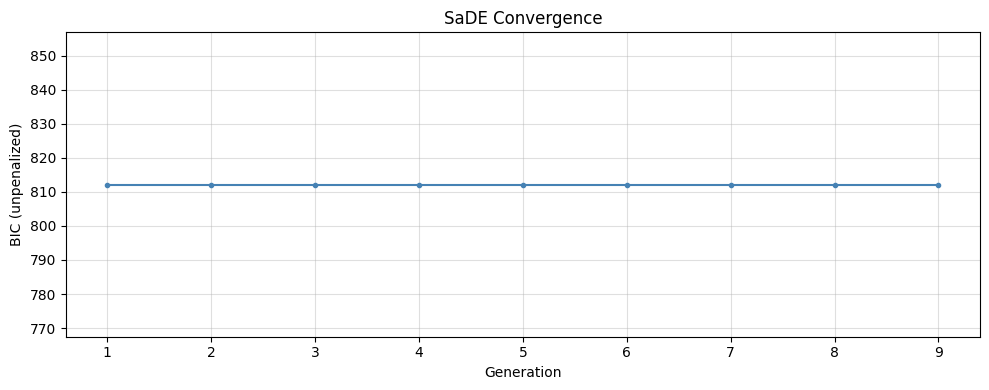


FIVE-MODEL COMPARISON

[1/5] Fitting Kaplan-Meier...
   Median survival time : 0.5576
   IBS (train)          : 0.1136

[2/5] Fitting Traditional Cox PH...
   C-index : 0.6454   BIC : 815.62   IBS : 0.1235

[3/5] Fitting Weibull AFT...
   C-index : 0.6368   AIC : 220.44   BIC : 236.93   IBS : 0.1004

[4/5] Fitting MFP Cox (traditional FP selection)...

  MFP converged in 2 cycle(s)
  α_select=0.05, α_function=0.05
  Power set S = [-2, -1, -0.5, 0, 0.5, 1, 2, 3]
    Age                   : FP1       powers=(-2, None)  [fp2_vs_null=0.0000  fp2_vs_lin=0.0391  fp2_vs_fp1=0.1972]
   C-index : 0.6454   BIC : 810.51   IBS : 0.1314

[5/5] Fitting FP Cox (SaDE)...
   C-index : 0.6551   BIC : 812.14   IBS : 0.1305

FIVE-MODEL SUMMARY TABLE
Metric           |       Kaplan-Meier |      Cox PH (trad) |        Weibull AFT |  MFP Cox (trad FP) |      FP Cox (SaDE)
------------------------------------------------------------------------
C-index          |                N/A |             0.6454 |    

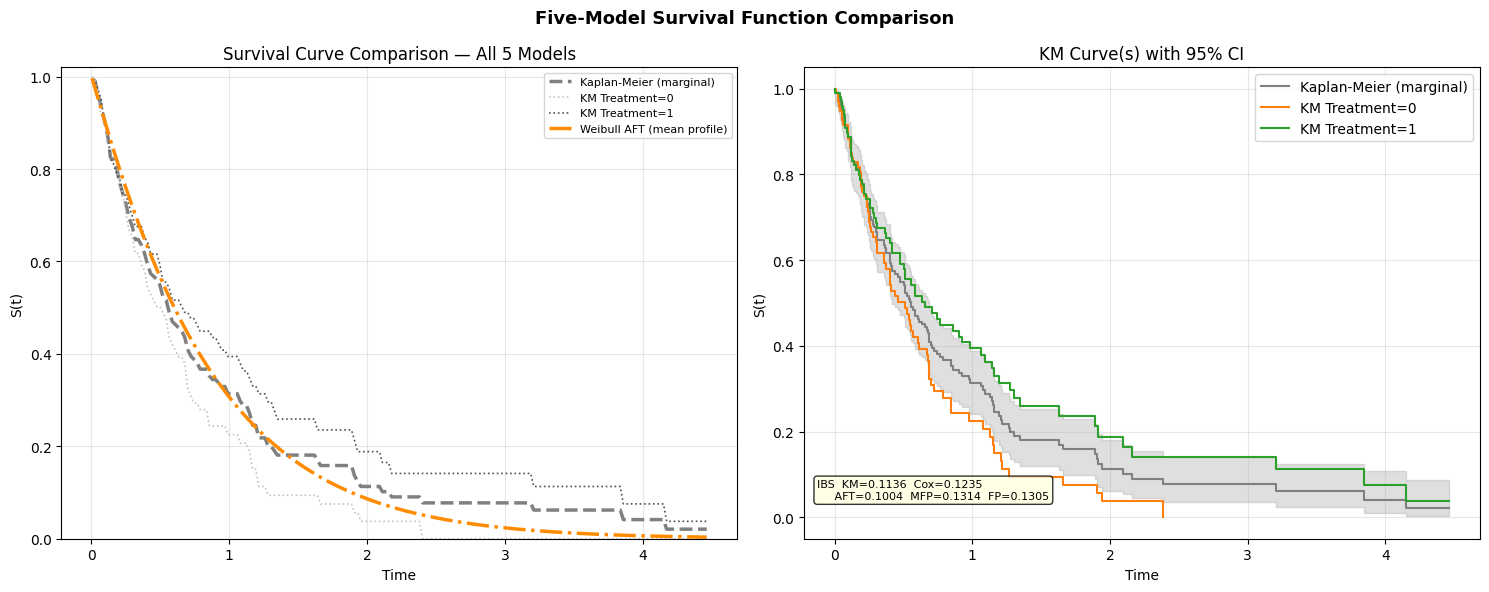


────────────────────────────────────────────────────────────────
  PH ASSUMPTION TEST — Traditional Cox PH
────────────────────────────────────────────────────────────────
  NOTE: PH tests apply ONLY to Cox models (not KM or Weibull AFT).
  Weibull AFT does not assume PH — it uses a different framework.
  H₀: log-HR constant over time  |  α = 0.05

  [A] lifelines check_assumptions():
  [!] Failed: ProportionalHazardMixin.check_assumptions() got an unexpected keyword argument 'warn'

  [B] Pearson ρ(Schoenfeld residual, ranked event time):
  ------------------------------------------------------------
  Age                                    ρ=-0.0809  p=0.3403

  ✓  No strong evidence of PH violation.
────────────────────────────────────────────────────────────────

────────────────────────────────────────────────────────────────
  PH ASSUMPTION TEST — MFP Cox (trad FP)
────────────────────────────────────────────────────────────────
  NOTE: PH tests apply ONLY to Cox models (not KM 

<lifelines.CoxPHFitter: fitted with 200 total observations, 59 right-censored observations>
             duration col = 'Time'
                event col = 'Event'
                   strata = ['Treatment', 'Sex']
      baseline estimation = breslow
   number of observations = 200
number of events observed = 141
   partial log-likelihood = -401.12
         time fit was run = 2026-04-05 13:39:19 UTC

---
             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                    
Age_fp1_2.5  0.22      1.24      0.06            0.10            0.33                1.10                1.40
Age_fp2_3   -0.07      0.93      0.02           -0.11           -0.03                0.89                0.97

             cmp to     z      p  -log2(p)
covariate                                 
Age_fp1_2.5    0.00  3.56 <0.005     11.39
Age_fp2_3      0.00 -3.33 <0.005     10.16
---
Concordance = 0.66
Partial AIC = 806.25
log-likelihood ratio test = 32.38 on 2 df
-log2(p) of ll-ratio test = 23.36


CROSS-VALIDATION  (5-fold, metric=concordance_index)
  Models: Cox PH, Weibull AFT, MFP Cox, FP Cox
  KM excluded (no covariates → no concordance index per fold).
  FP powers fixed post-selection; Cox/AFT coefficients re-estimated per fold.

  [1/4] Cox PH...
  [2/4] Weibull AFT...
  [3/4] MFP Cox...
  [4/4] FP Cox...

                                            Mean        Std        Min        Max
  -------------------------------------------------------------------
  Cox PH (traditional)                    0.6560     0.0526     0.5668     0.7072
  Weibull AFT                             0.6334     0.0388     0.5907     0.6895
  MFP Cox (trad FP)                       0.6480     0.0257     0.6103     0.6856
  FP Cox (SaDE)                           0.6446     0.0386     0.5930     0.7080

  Per-fold scores:
  Fold     Cox PH (traditional)            Weibull AFT      MFP Cox (trad FP)          FP Cox (SaDE)
  ---------------------------------------------------------------------------

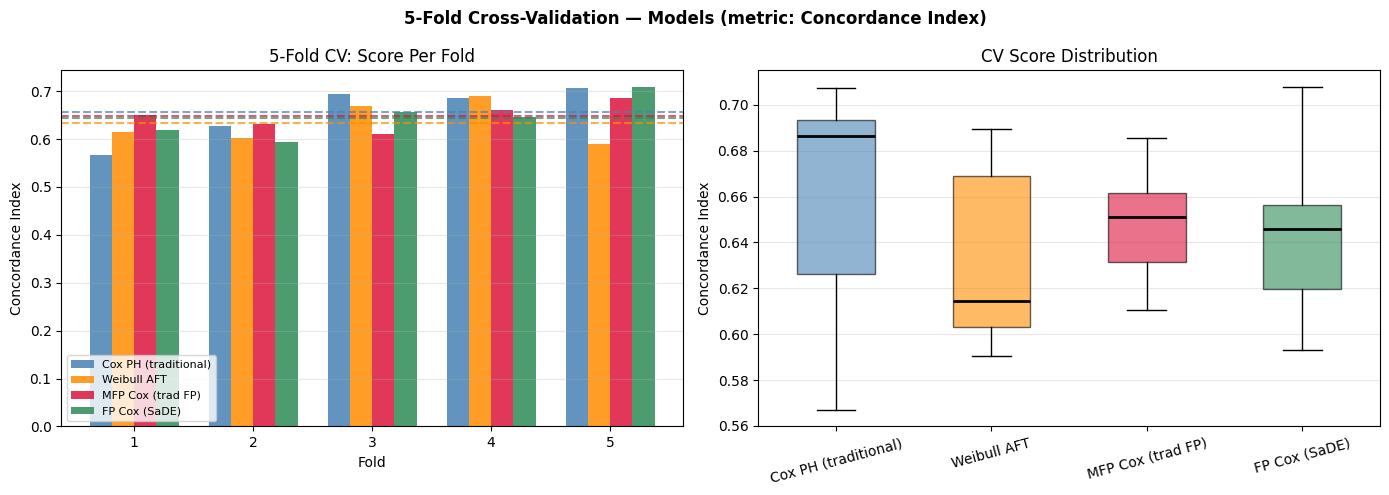


ALGORITHM VALIDATION — 25 independent SaDE runs
  Early stop at gen 9 (no improvement for 8 gens, evals: 240)
  Run  1 (seed=0): obj=810.5067  gens=9  powers=[('None', '-2')]  types=['FP2']
  Early stop at gen 11 (no improvement for 8 gens, evals: 288)
  Run  2 (seed=1): obj=810.5067  gens=11  powers=[('None', '-2')]  types=['FP2']
  Early stop at gen 14 (no improvement for 8 gens, evals: 360)
  Run  3 (seed=2): obj=810.5067  gens=14  powers=[('None', '-2')]  types=['FP2']
  Early stop at gen 14 (no improvement for 8 gens, evals: 360)
  Run  4 (seed=3): obj=810.5067  gens=14  powers=[('None', '-2')]  types=['FP2']
  Early stop at gen 10 (no improvement for 8 gens, evals: 264)
  Run  5 (seed=4): obj=810.5067  gens=10  powers=[('None', '-2')]  types=['FP2']
  Early stop at gen 21 (no improvement for 8 gens, evals: 528)
  Run  6 (seed=5): obj=810.5067  gens=21  powers=[('None', '-2')]  types=['FP2']
  Early stop at gen 15 (no improvement for 8 gens, evals: 384)
  Run  7 (seed=6): obj=810

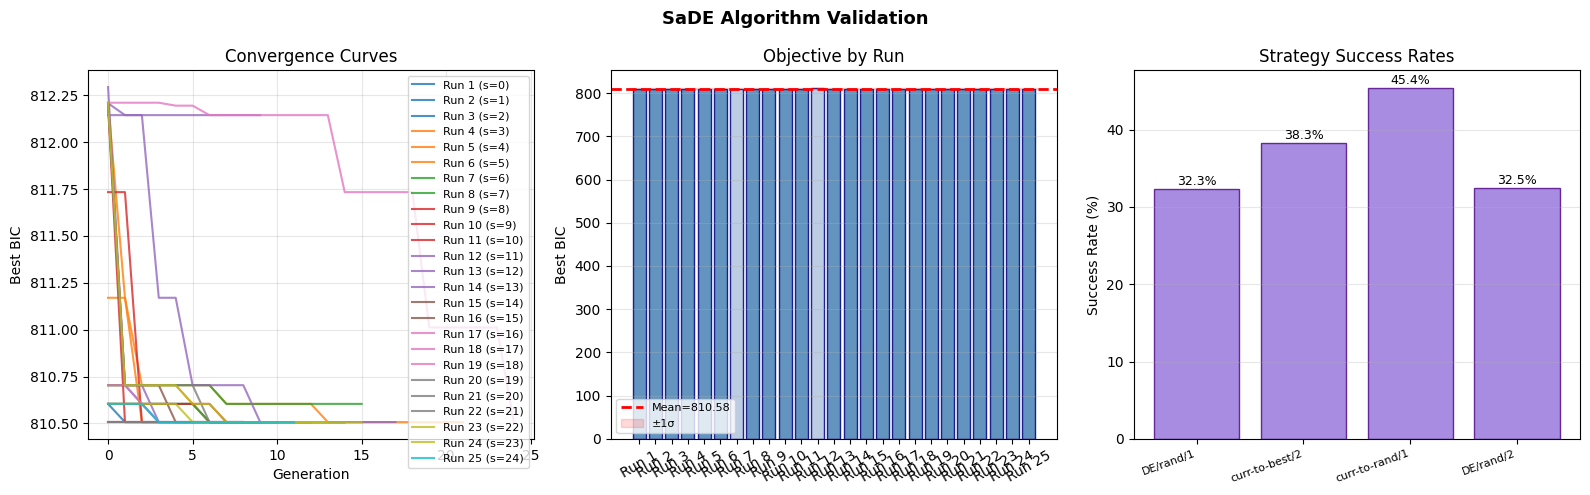


  Power Selection Frequency (across 25 runs):
    Age:
      (-2, None)           [FP1] :  12/25 ( 48.0%)
      (None, -2)           [FP2] :  11/25 ( 44.0%)
      (None, -1.5)         [FP2] :   1/25 (  4.0%)
      (3, 2.5)             [FP2] :   1/25 (  4.0%)


In [21]:
import pandas as pd

# ── Dataset 1: Simulated ────────────────────────────────────────────────────
sd_df = pd.read_csv('../../../data/preprocess-data/preprocess_simulated_data.csv')
optimizer_sd = FPCoxOptimizer(
    df           = sd_df,
    covariates   = ['Age'],
    duration_col = 'Time',
    event_col    = 'Event',
    strata_cols  = ['Treatment', 'Sex'],
)
optimizer_sd.optimize(maxiter=25, popsize=12, seed=42)
print('\nFP Cox model summary (Simulated):')
optimizer_sd.final_fp_model.print_summary()

cv_sd  = optimizer_sd.run_cross_validation(k=5, scoring_method='concordance_index', seed=0)
val_sd = optimizer_sd.validate_algorithm(n_runs=25, seeds=list(range(25)), maxiter=25, popsize=12)

Starting SaDE v9  (pure BIC minimisation)
  FP covariates : ['age', 'albumin', 'protime', 'stage', 'log_bili', 'log_chol', 'log_copper', 'log_alk_phos', 'log_ast', 'log_trig']
  Simultaneous  : 10 covariates | dim=20  (FP2 max; FP1 if p2=None)
  Strata        : ['edema']
  Scales        : age÷10, albumin÷1, protime÷10, stage÷1, log_bili÷1, log_chol÷1, log_copper÷1, log_alk_phos÷1, log_ast÷1, log_trig÷1
  n=418, n_events=161
  Pop=240 | MaxGens=25 | Budget=6000
  Early stop at gen 17 (no improvement for 8 gens, evals: 4320)

--- Optimal Power Selection ---
  age                   : p1=None    p2=-2       [FP2]
  albumin               : p1=-0.5    p2=None     [FP1]
  protime               : p1=0.25    p2=None     [FP1]
  stage                 : p1=-1      p2=2.5      [FP2]
  log_bili              : p1=None    p2=0        [FP2]
  log_chol              : p1=1.5     p2=0        [FP2]
  log_copper            : p1=None    p2=-1       [FP2]
  log_alk_phos          : p1=None    p2=1.5      [FP2

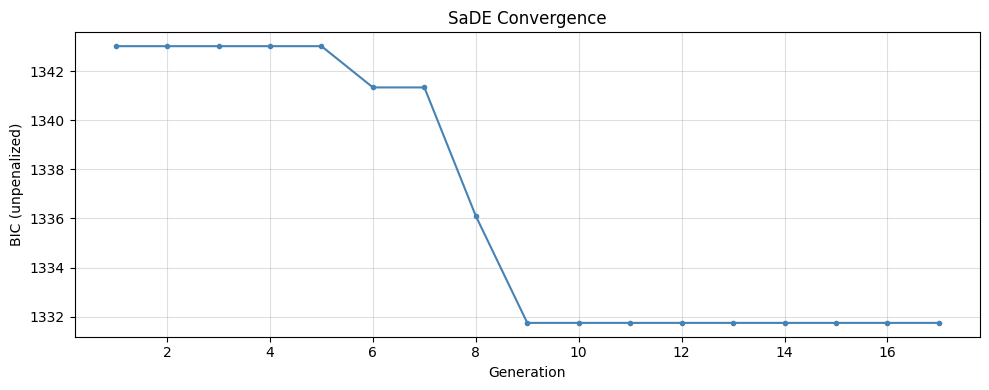


FIVE-MODEL COMPARISON

[1/5] Fitting Kaplan-Meier...
   Median survival time : 3395.0000
   IBS (train)          : 0.1953

[2/5] Fitting Traditional Cox PH...
   C-index : 0.8303   BIC : 1331.72   IBS : 0.2644

[3/5] Fitting Weibull AFT...
   C-index : 0.8488   AIC : 2839.64   BIC : 2892.10   IBS : 0.1314

[4/5] Fitting MFP Cox (traditional FP selection)...

  MFP converged in 2 cycle(s)
  α_select=0.05, α_function=0.05
  Power set S = [-2, -1, -0.5, 0, 0.5, 1, 2, 3]
    age                   : linear    powers=(1, None)  [fp2_vs_null=0.0001  fp2_vs_lin=0.2947]
    albumin               : dropped   powers=(None, None)  [fp2_vs_null=0.0675]
    protime               : dropped   powers=(None, None)  [fp2_vs_null=0.0694]
    stage                 : linear    powers=(1, None)  [fp2_vs_null=0.0077  fp2_vs_lin=0.9837]
    log_bili              : FP2       powers=(-2, -1)  [fp2_vs_null=0.0000  fp2_vs_lin=0.0010  fp2_vs_fp1=0.0312]
    log_chol              : dropped   powers=(None, None)  [f

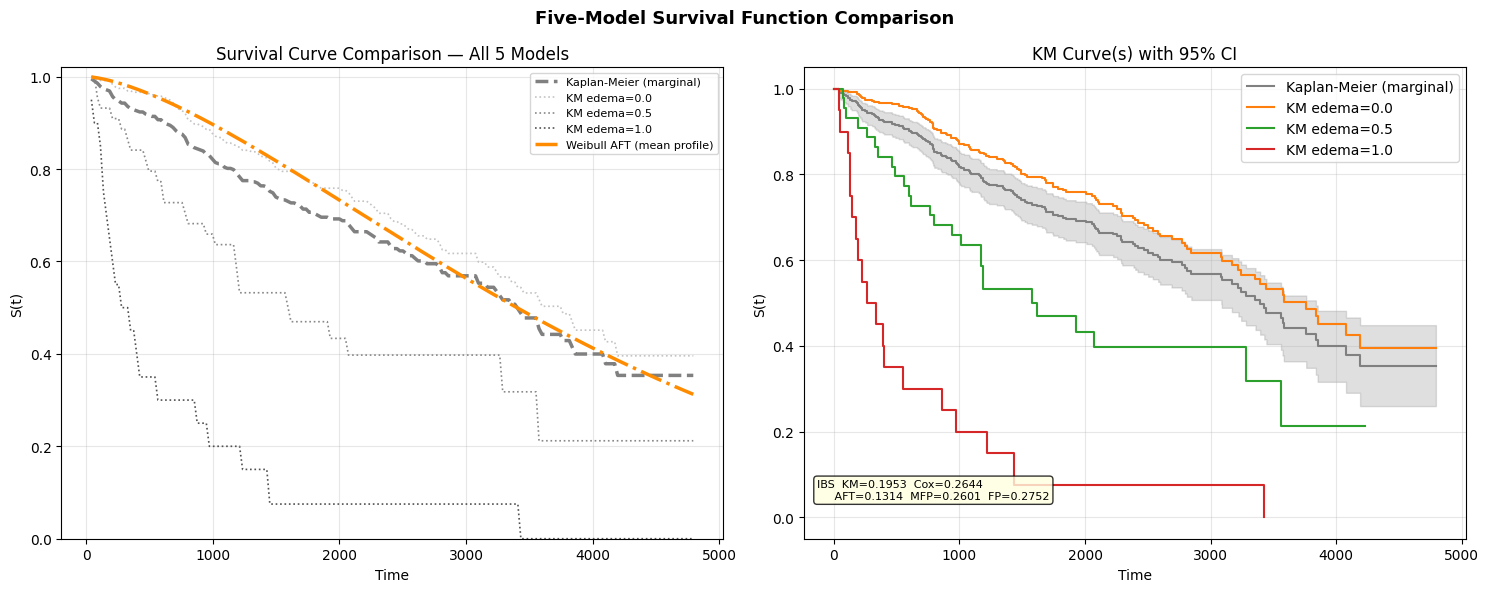


────────────────────────────────────────────────────────────────
  PH ASSUMPTION TEST — Traditional Cox PH
────────────────────────────────────────────────────────────────
  NOTE: PH tests apply ONLY to Cox models (not KM or Weibull AFT).
  Weibull AFT does not assume PH — it uses a different framework.
  H₀: log-HR constant over time  |  α = 0.05

  [A] lifelines check_assumptions():
  [!] Failed: ProportionalHazardMixin.check_assumptions() got an unexpected keyword argument 'warn'

  [B] Pearson ρ(Schoenfeld residual, ranked event time):
  ------------------------------------------------------------
  age                                    ρ=+0.0574  p=0.4694
  albumin                                ρ=+0.0097  p=0.9028
  protime                                ρ=-0.0374  p=0.6372
  stage                                  ρ=+0.0559  p=0.4812
  log_bili                               ρ=-0.0376  p=0.6358
  log_chol                               ρ=-0.0745  p=0.3477
  log_copper            

<lifelines.CoxPHFitter: fitted with 418 total observations, 257 right-censored observations>
             duration col = 'time'
                event col = 'status_binary'
                   strata = edema
      baseline estimation = breslow
   number of observations = 418
number of events observed = 161
   partial log-likelihood = -635.38
         time fit was run = 2026-04-05 14:36:47 UTC

---
                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                             
age_fp_-2           -24.03      0.00      5.58          -34.97          -13.09                0.00                0.00
albumin_fp_-0.5       6.79    890.01      2.37            2.14           11.44                8.54            92746.68
protime_fp_0.25       9.53  13729.26      3.52            2.62           16.43               13.79            1.37e+07
stage_fp1_-1         -0.98      0.38      1.27           -3.47            1.52                0.03                4.58
stage_fp2_2.5         0.01      1.01      0.02           -0.02            0.04                0.98                1.04
log_bili_fp_0         1.41      4.09      0.20            1.01            1.81                2.74                6.09
log_chol_fp1_0      -15.77      0.00     14.41          -44.01           12.47                0.00            2.61e+05
log_chol_fp2_1.5      0.68      1.98      0.63           -0.55            1.91                0.58                6.76
log_copper_fp_-1     -4.07      0.02      2.55           -9.06            0.92                0.00                2.52
log_alk_phos_fp_1.5  -0.01      0.99      0.03           -0.07            0.04                0.93                1.05
log_ast_fp1_-3       -0.80      0.45    117.85         -231.78          230.17                0.00            9.17e+99
log_ast_fp2_1.5       0.10      1.11      0.23           -0.34            0.55                0.71                1.73

                     cmp to     z      p  -log2(p)
covariate                                         
age_fp_-2              0.00 -4.30 <0.005     15.87
albumin_fp_-0.5        0.00  2.86 <0.005      7.90
protime_fp_0.25        0.00  2.71   0.01      7.19
stage_fp1_-1           0.00 -0.77   0.44      1.17
stage_fp2_2.5          0.00  0.88   0.38      1.41
log_bili_fp_0          0.00  6.91 <0.005     37.58
log_chol_fp1_0         0.00 -1.09   0.27      1.87
log_chol_fp2_1.5       0.00  1.09   0.28      1.86
log_copper_fp_-1       0.00 -1.60   0.11      3.18
log_alk_phos_fp_1.5    0.00 -0.47   0.64      0.65
log_ast_fp1_-3         0.00 -0.01   0.99      0.01
log_ast_fp2_1.5        0.00  0.46   0.64      0.64
---
Concordance = 0.83
Partial AIC = 1294.77
log-likelihood ratio test = 188.13 on 12 df
-log2(p) of ll-ratio test = 109.76


CROSS-VALIDATION  (5-fold, metric=concordance_index)
  Models: Cox PH, Weibull AFT, MFP Cox, FP Cox
  KM excluded (no covariates → no concordance index per fold).
  FP powers fixed post-selection; Cox/AFT coefficients re-estimated per fold.

  [1/4] Cox PH...
  [2/4] Weibull AFT...
  [3/4] MFP Cox...
  [4/4] FP Cox...

                                            Mean        Std        Min        Max
  -------------------------------------------------------------------
  Cox PH (traditional)                    0.8368     0.0309     0.7915     0.8826
  Weibull AFT                             0.8402     0.0242     0.8038     0.8769
  MFP Cox (trad FP)                       0.8250     0.0174     0.7919     0.8417
  FP Cox (SaDE)                           0.8334     0.0383     0.7895     0.8938

  Per-fold scores:
  Fold     Cox PH (traditional)            Weibull AFT      MFP Cox (trad FP)          FP Cox (SaDE)
  ---------------------------------------------------------------------------

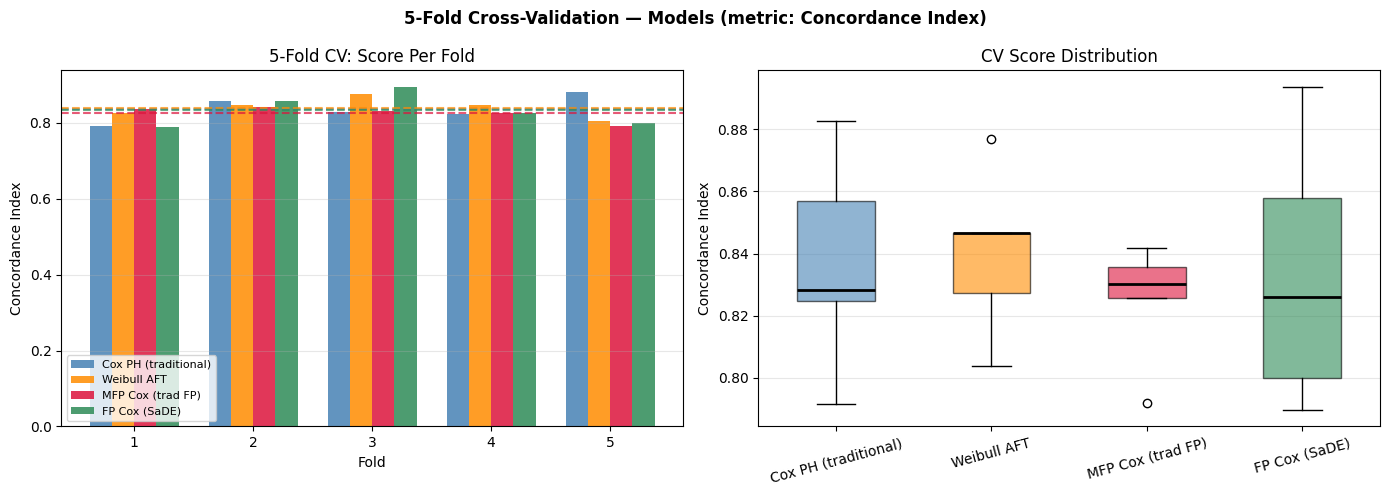

In [22]:
# ── Dataset 2: PBC (Primary Biliary Cirrhosis — Mayo Clinic) ─────────────
# Source: https://www.kaggle.com/datasets/jixing475/mayo-clinic-primary-biliary-cirrhosis-data
# Preprocessing matches coxph_model_fixed_v2.ipynb (EDA notebook):
#   - status_binary: status==2 (death) → 1, else → 0
#   - Missing values: continuous → median imputation; stage NaN rows dropped
#   - Skewed biomarkers (|skew|>1) log1p-transformed: bili, chol, copper,
#     alk.phos, ast, trig → log_bili, log_chol, log_copper, log_alk_phos,
#     log_ast, log_trig
#   - Covariates: age, albumin, protime, stage + 6 log-transformed biomarkers
#   - Strata: edema (PH violation in EDA)

pbc_df = pd.read_csv('../../../data/preprocess-data/preprocess_pbc.csv',
                      index_col=0)

PBC_COVARIATES = ['age', 'albumin', 'protime', 'stage',
                  'log_bili', 'log_chol', 'log_copper',
                  'log_alk_phos', 'log_ast', 'log_trig']
PBC_STRATA     = ['edema']

optimizer_pbc = FPCoxOptimizer(
    df           = pbc_df,
    covariates   = PBC_COVARIATES,
    duration_col = 'time',
    event_col    = 'status_binary',
    strata_cols  = PBC_STRATA,
)
optimizer_pbc.optimize(maxiter=25, popsize=12, seed=42)
print('\nFP Cox model summary (PBC):')
optimizer_pbc.final_fp_model.print_summary()

cv_pbc  = optimizer_pbc.run_cross_validation(k=5, scoring_method='concordance_index', seed=0)
# val_pbc = optimizer_pbc.validate_algorithm(n_runs=25, seeds=list(range(25)), maxiter=25, popsize=12)


Starting SaDE v9  (pure BIC minimisation)
  FP covariates : ['log_pgr', 'log_nodes', 'log_er', 'age', 'size']
  Simultaneous  : 5 covariates | dim=10  (FP2 max; FP1 if p2=None)
  Strata        : ['meno', 'grade', 'hormon']
  Scales        : log_pgr÷1, log_nodes÷1, log_er÷1, age÷10, size÷10
  n=686, n_events=299
  Pop=120 | MaxGens=25 | Budget=3000
  Early stop at gen 16 (no improvement for 8 gens, evals: 2040)

--- Optimal Power Selection ---
  log_pgr               : p1=None    p2=2.5      [FP2]
  log_nodes             : p1=0.25    p2=-2.5     [FP2]
  log_er                : p1=None    p2=None     [FP1]
  age                   : p1=0.25    p2=-2       [FP2]
  size                  : p1=-1      p2=None     [FP1]

  Best BIC  : 2250.0048
  Gens      : 16
  Evals     : 2040 (cache hits: 196)

--- Strategy Usage ---
  DE/rand/1                   : used= 452  success= 129  rate= 28.5%
  DE/curr-to-best/2           : used= 531  success= 207  rate= 39.0%
  DE/curr-to-rand/1           : used=

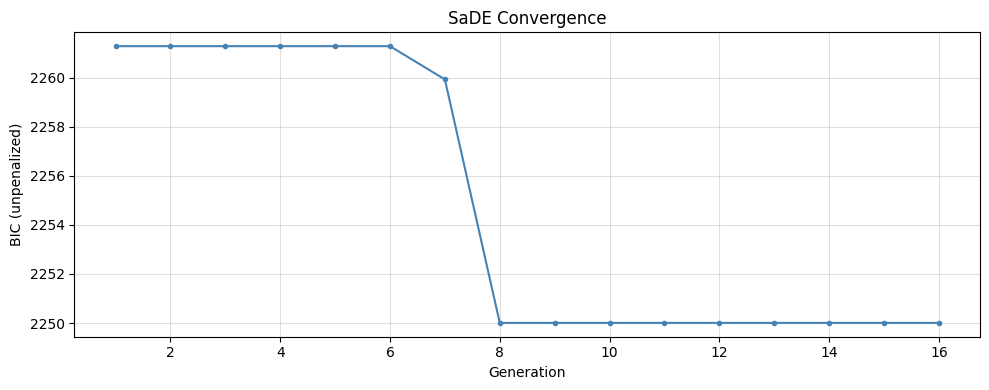


FIVE-MODEL COMPARISON

[1/5] Fitting Kaplan-Meier...
   Median survival time : 1807.0000
   IBS (train)          : 0.1950

[2/5] Fitting Traditional Cox PH...
   C-index : 0.6668   BIC : 2266.30   IBS : 0.2285

[3/5] Fitting Weibull AFT...
   C-index : 0.6986   AIC : 5152.32   BIC : 5197.63   IBS : 0.1551

[4/5] Fitting MFP Cox (traditional FP selection)...

  MFP converged in 2 cycle(s)
  α_select=0.05, α_function=0.05
  Power set S = [-2, -1, -0.5, 0, 0.5, 1, 2, 3]
    log_pgr               : linear    powers=(1, None)  [fp2_vs_null=0.0000  fp2_vs_lin=0.5876]
    log_nodes             : linear    powers=(1, None)  [fp2_vs_null=0.0000  fp2_vs_lin=0.1790]
    log_er                : dropped   powers=(None, None)  [fp2_vs_null=0.9805]
    age                   : FP2       powers=(-2, -1)  [fp2_vs_null=0.0034  fp2_vs_lin=0.0017  fp2_vs_fp1=0.0249]
    size                  : dropped   powers=(None, None)  [fp2_vs_null=0.2475]
   C-index : 0.6774   BIC : 2247.62   IBS : 0.2315

[5/5] Fit

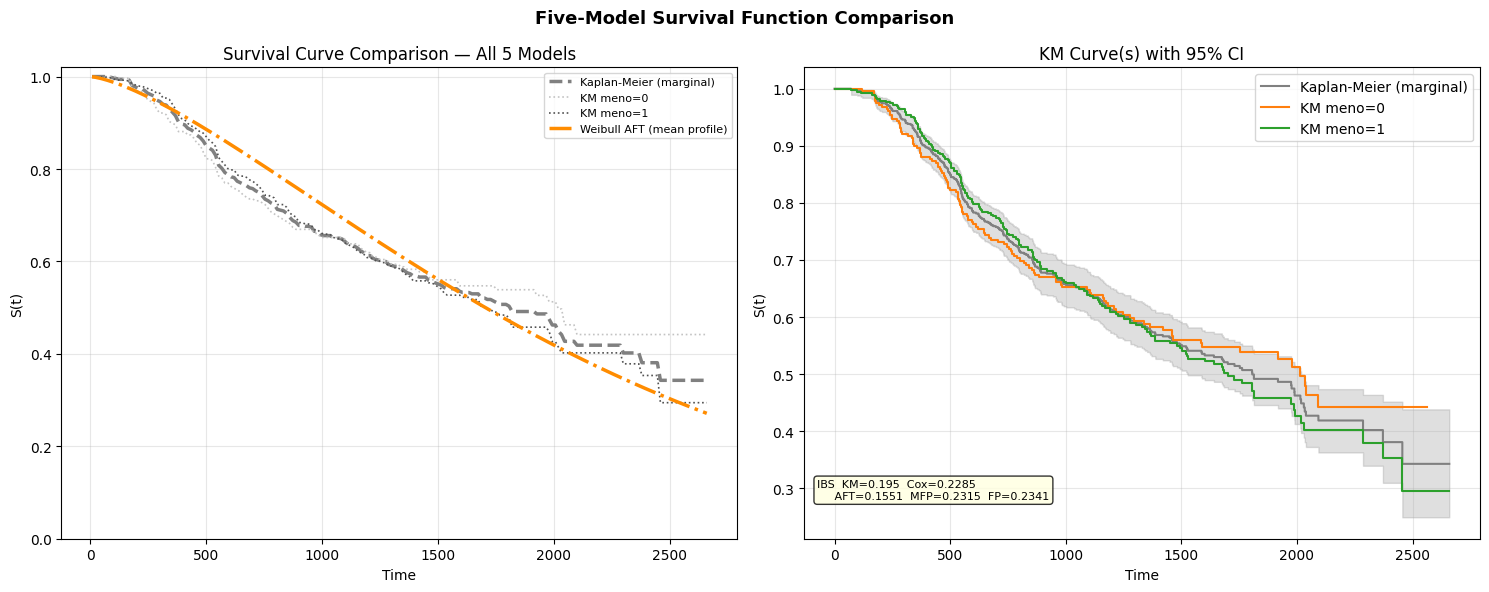


────────────────────────────────────────────────────────────────
  PH ASSUMPTION TEST — Traditional Cox PH
────────────────────────────────────────────────────────────────
  NOTE: PH tests apply ONLY to Cox models (not KM or Weibull AFT).
  Weibull AFT does not assume PH — it uses a different framework.
  H₀: log-HR constant over time  |  α = 0.05

  [A] lifelines check_assumptions():
  [!] Failed: ProportionalHazardMixin.check_assumptions() got an unexpected keyword argument 'warn'

  [B] Pearson ρ(Schoenfeld residual, ranked event time):
  ------------------------------------------------------------
  log_pgr                                ρ=-0.0168  p=0.7730
  log_nodes                              ρ=-0.1605  p=0.0054
  log_er                                 ρ=-0.0417  p=0.4727
  age                                    ρ=+0.1373  p=0.0175
  size                                   ρ=-0.0114  p=0.8438

  ✓  No strong evidence of PH violation.
───────────────────────────────────────────

<lifelines.CoxPHFitter: fitted with 686 total observations, 387 right-censored observations>
             duration col = 'rfstime'
                event col = 'status'
                   strata = ['meno', 'grade', 'hormon']
      baseline estimation = breslow
   number of observations = 686
number of events observed = 299
   partial log-likelihood = -1107.90
         time fit was run = 2026-04-05 14:57:14 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
log_pgr_fp_2.5     -0.01      0.99      0.00           -0.02           -0.01                0.98                0.99
log_nodes_fp1_-2.5  0.33      1.39      0.14            0.05            0.61                1.05                1.83
log_nodes_fp2_0.25  5.19    179.35      0.96            3.32            7.06               27.58             1166.42
age_fp1_-2         30.84  2.47e+13      6.63           17.85           43.83            5.65e+07            1.08e+19
age_fp2_0.25        6.98   1079.33      2.30            2.48           11.48               11.99            97174.15
size_fp_-1         -0.74      0.48      0.34           -1.41           -0.07                0.25                0.93

                    cmp to     z      p  -log2(p)
covariate                                        
log_pgr_fp_2.5        0.00 -4.98 <0.005     20.57
log_nodes_fp1_-2.5    0.00  2.33   0.02      5.65
log_nodes_fp2_0.25    0.00  5.43 <0.005     24.10
age_fp1_-2            0.00  4.65 <0.005     18.22
age_fp2_0.25          0.00  3.04 <0.005      8.73
size_fp_-1            0.00 -2.16   0.03      5.03
---
Concordance = 0.68
Partial AIC = 2227.80
log-likelihood ratio test = 117.54 on 6 df
-log2(p) of ll-ratio test = 73.98


CROSS-VALIDATION  (5-fold, metric=concordance_index)
  Models: Cox PH, Weibull AFT, MFP Cox, FP Cox
  KM excluded (no covariates → no concordance index per fold).
  FP powers fixed post-selection; Cox/AFT coefficients re-estimated per fold.

  [1/4] Cox PH...
  [2/4] Weibull AFT...
  [3/4] MFP Cox...
  [4/4] FP Cox...

                                            Mean        Std        Min        Max
  -------------------------------------------------------------------
  Cox PH (traditional)                    0.6733     0.0092     0.6636     0.6903
  Weibull AFT                             0.6933     0.0156     0.6650     0.7111
  MFP Cox (trad FP)                       0.6916     0.0162     0.6696     0.7127
  FP Cox (SaDE)                           0.6970     0.0223     0.6537     0.7132

  Per-fold scores:
  Fold     Cox PH (traditional)            Weibull AFT      MFP Cox (trad FP)          FP Cox (SaDE)
  ---------------------------------------------------------------------------

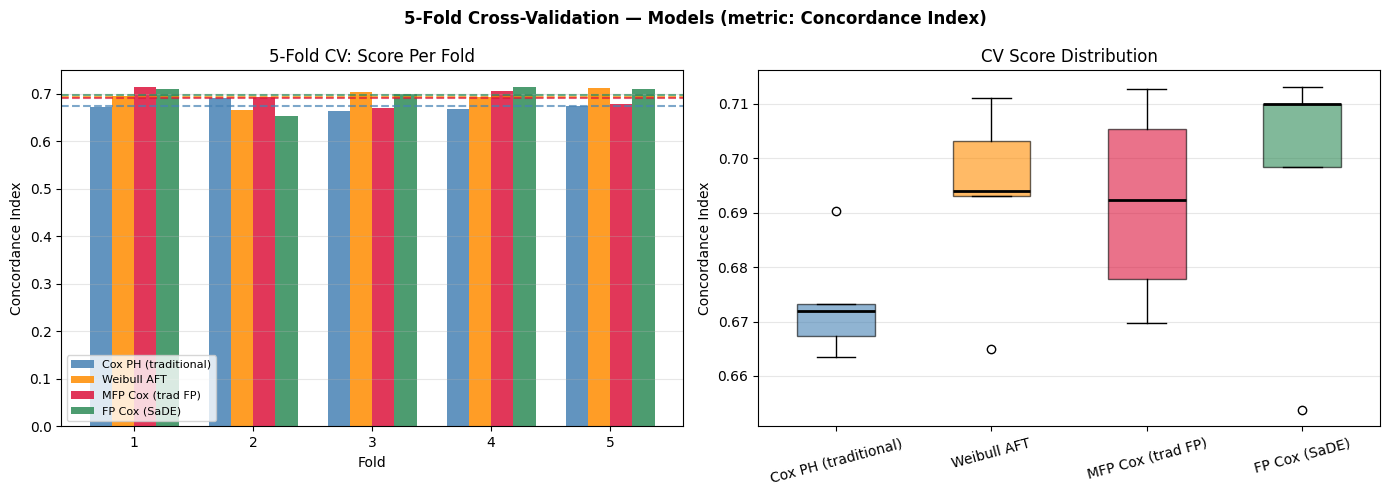

In [23]:
# ── Dataset 3: GBSG ─────────────────────────────────────────────────────────
gb_df = pd.read_csv('../../../data/preprocess-data/preprocess_gbsg.csv')
GB_COVARIATES = ['log_pgr', 'log_nodes', 'log_er', 'age', 'size']
GB_STRATA     = ['meno', 'grade', 'hormon']
optimizer_gb = FPCoxOptimizer(
    df           = gb_df,
    covariates   = GB_COVARIATES,
    duration_col = 'rfstime',
    event_col    = 'status',
    strata_cols  = GB_STRATA,
)
optimizer_gb.optimize(maxiter=25, popsize=12, seed=42)
print('\nFP Cox model summary (GBSG):')
optimizer_gb.final_fp_model.print_summary()

cv_gb  = optimizer_gb.run_cross_validation(k=5, scoring_method='concordance_index', seed=0)
# val_gb = optimizer_gb.validate_algorithm(n_runs=25, seeds=list(range(25)), maxiter=25, popsize=12)

## Interpretation Reference

### Five-model comparison

| | Kaplan-Meier | Cox PH | Weibull AFT | MFP Cox | FP Cox (SaDE) |
|---|---|---|---|---|---|
| **Assumption** | None | PH | Weibull shape | PH | PH |
| **Covariates** | No | Linear | Linear | FSP-selected FP | SaDE-optimised FP |
| **Power selection** | — | — | — | LRT/FSP (α=0.05) | BIC minimisation |
| **Power set** | — | — | — | S={−2,−1,−0.5,0,0.5,1,2,3} | Extended (16 values) |
| **BIC convention** | — | n_events, partial LL | n_total, full LL | n_events, partial LL | n_events, partial LL |

### ΔBIC interpretation (Raftery 1995)

| ΔBIC | Evidence |
|---|---|
| 0 – 2 | Weak — models essentially equivalent |
| 2 – 6 | Positive — lower-BIC model preferred |
| 6 – 10 | Strong |
| > 10 | Very strong |

### MFP vs SaDE-FP

| Aspect | MFP (traditional) | SaDE-FP (proposed) |
|---|---|---|
| **Search strategy** | Sequential FSP per variable | Simultaneous global optimisation |
| **Selection criterion** | Likelihood Ratio Tests (α-based) | BIC minimisation |
| **Power set** | 8 standard powers | 16 extended powers |
| **Variable selection** | Built-in (α_select) | Via NA power index |

## Simulation Study

Monte-Carlo subsample simulation: 1 000 draws of 90% of each dataset (stratified by event status). FP/MFP powers fixed from `optimize()`; only coefficients re-estimated. Models: Cox PH, Weibull AFT, MFP Cox, FP Cox. Metrics: C-index, BIC, IBS (train 90% + test 10% holdout).

In [24]:

# -----------------------------------------------------------------------
# Simulation Study — run_simulation_study()
# -----------------------------------------------------------------------
# FP/MFP powers FIXED from optimize(). Each iteration draws 90% stratified
# subsample, refits four models (Cox PH, Weibull AFT, MFP Cox, FP Cox),
# collects C-index, BIC, IBS (train 90% + test 10% holdout).
# -----------------------------------------------------------------------

def run_simulation_study(
    self,
    n_sims: int = 1000,
    sample_frac: float = 0.90,
    seed: int = 0,
    show_progress_every: int = 100,
):
    """
    Bootstrap simulation study (subsample without replacement).

    Parameters
    ----------
    n_sims          : int   — number of simulation iterations (default 1000)
    sample_frac     : float — fraction of data sampled each iteration (default 0.90)
    seed            : int   — master RNG seed for reproducibility
    show_progress_every : int — print progress every N iterations

    Requirements
    ------------
    Must call optimize() before this method.

    Returns
    -------
    dict with keys:
        'metrics_df'   : pd.DataFrame  (n_sims × metric columns)
        'coef_cox'     : pd.DataFrame  (n_sims × Cox PH coefficient columns)
        'coef_aft'     : pd.DataFrame  (n_sims × Weibull AFT parameter columns)
        'coef_fp'      : pd.DataFrame  (n_sims × FP Cox coefficient columns)
        'summary'      : pd.DataFrame  (mean / std / CV% / 2.5% / 97.5%)
        'n_sims'       : int
        'sample_frac'  : float
    """
    if self._df_trad_final is None or self._df_fp_final is None:
        raise RuntimeError("Call optimize() before run_simulation_study().")

    bar = "=" * 72
    print(f"\n{bar}")
    print(f"SIMULATION STUDY  (n_sims={n_sims}, sample_frac={sample_frac:.0%})")
    print(bar)
    print(f"  FP powers FIXED from prior optimize() call.")
    print(f"  Models: Cox PH, Weibull AFT, MFP Cox, FP Cox")
    print(f"  Each iteration: {int(len(self.df)*sample_frac)} / {len(self.df)} rows "
          f"(stratified by event status)")
    print(f"  IBS reported: training (90%) AND test (10% holdout)\n")

    rng    = np.random.default_rng(seed)
    strata = self.strata_cols or None

    # --- Pre-build the AFT column list (same logic as _fit_final_models) ---
    seen, trad_cols = set(), []
    for c in (self.covariates + self.strata_cols +
              [self.duration_col, self.event_col]):
        if c not in seen:
            trad_cols.append(c)
            seen.add(c)

    seen2, aft_cols = set(), []
    for c in (self.covariates + self.strata_cols +
              [self.duration_col, self.event_col]):
        if c not in seen2:
            aft_cols.append(c)
            seen2.add(c)

    # --- Storage ---
    metrics_rows = []
    coef_cox_rows = []
    coef_aft_rows = []
    coef_fp_rows  = []
    coef_mfp_rows = []

    n_failed = 0

    for sim_i in range(n_sims):
        # ── Stratified subsample (preserves event rate) ──────────────────
        events_idx   = self.df.index[self.df[self.event_col].astype(bool)]
        censored_idx = self.df.index[~self.df[self.event_col].astype(bool)]

        n_ev  = max(1, int(round(len(events_idx)   * sample_frac)))
        n_cen = max(1, int(round(len(censored_idx) * sample_frac)))

        sampled_ev  = rng.choice(events_idx,   size=n_ev,  replace=False)
        sampled_cen = rng.choice(censored_idx, size=n_cen, replace=False)
        idx_sample  = np.concatenate([sampled_ev, sampled_cen])

        df_sim = self.df.loc[idx_sample].copy()

        # ── 10 % holdout — used as the true test set for IBS ────────────
        holdout_idx = self.df.index.difference(pd.Index(idx_sample))
        df_hold     = self.df.loc[holdout_idx].copy() if len(holdout_idx) > 0 else None

        # ── Rebuild preprocessed sub-dataframes ─────────────────────────
        df_sim_trad = df_sim[trad_cols].copy()

        # FP features on the subsample
        fp_feat = self._generate_fp_features_on(
            df_sim, self.covariates, self.best_powers)
        if fp_feat is None:
            n_failed += 1
            continue

        # Build FP dataframe for the subsample
        const_cols_sim = {
            self.duration_col: df_sim[self.duration_col].values,
            self.event_col:    df_sim[self.event_col].values,
        }
        for c in self.strata_cols:
            const_cols_sim[c] = df_sim[c].values
        df_sim_fp = pd.DataFrame(const_cols_sim, index=df_sim.index)
        for col_name, arr in fp_feat.items():
            df_sim_fp[col_name] = arr

        df_sim_aft = df_sim[aft_cols].copy()

        # ── Build holdout dataframes for out-of-sample IBS ──────────────
        has_holdout   = False
        df_hold_trad  = None
        df_hold_aft   = None
        df_hold_fp    = None
        y_holdout     = None
        if df_hold is not None and int(df_hold[self.event_col].sum()) >= 2:
            try:
                df_hold_trad = df_hold[trad_cols].copy()
                df_hold_aft  = df_hold[aft_cols].copy()
                fp_feat_hold = self._generate_fp_features_on(
                    df_hold, self.covariates, self.best_powers)
                if fp_feat_hold is not None:
                    _const_hold = {
                        self.duration_col: df_hold[self.duration_col].values,
                        self.event_col:    df_hold[self.event_col].values,
                    }
                    for c in self.strata_cols:
                        _const_hold[c] = df_hold[c].values
                    df_hold_fp = pd.DataFrame(_const_hold, index=df_hold.index)
                    for _cn, _arr in fp_feat_hold.items():
                        df_hold_fp[_cn] = _arr
                    if HAS_SKSURV:
                        y_holdout = Surv.from_arrays(
                            event=df_hold[self.event_col].astype(bool).values,
                            time =df_hold[self.duration_col].values)
                    has_holdout = True
            except Exception:
                has_holdout = False

        n_ev_sim    = int(df_sim[self.event_col].sum())
        n_total_sim = len(df_sim)

        row_metrics = {}
        row_cox     = {}
        row_aft     = {}
        row_fp      = {}

        # ── 1. Cox PH ────────────────────────────────────────────────────
        try:
            cph = CoxPHFitter(penalizer=0.0)
            cph.fit(df_sim_trad, duration_col=self.duration_col,
                    event_col=self.event_col, strata=strata,
                    show_progress=False)

            k_t   = len(cph.params_)
            bic_t = -2 * cph.log_likelihood_ + k_t * np.log(n_ev_sim)

            row_metrics["cox_cindex"] = cph.concordance_index_
            row_metrics["cox_bic"]    = bic_t

            # IBS — training (90%) and test (10% holdout)
            if HAS_SKSURV:
                try:
                    y_train_cox = Surv.from_arrays(
                        event=df_sim[self.event_col].astype(bool).values,
                        time =df_sim[self.duration_col].values)

                    # Training IBS (same data the model was fitted on)
                    t_lo_tr = df_sim[self.duration_col].min()
                    t_hi_tr = df_sim[self.duration_col].max() * 0.999
                    if t_lo_tr < t_hi_tr:
                        times_cox_tr = np.linspace(t_lo_tr, t_hi_tr, 80)
                        sf_cox_tr = cph.predict_survival_function(
                            df_sim_trad, times=times_cox_tr)
                        row_metrics["cox_ibs_train"] = float(
                            integrated_brier_score(
                                y_train_cox, y_train_cox,
                                sf_cox_tr.T.values, times_cox_tr))
                    else:
                        row_metrics["cox_ibs_train"] = np.nan

                    # Test IBS (10% holdout the model never saw)
                    if has_holdout and y_holdout is not None:
                        t_lo = max(df_sim[self.duration_col].min(),
                                   df_hold[self.duration_col].min())
                        t_hi = min(df_sim[self.duration_col].max(),
                                   df_hold[self.duration_col].max()) * 0.999
                        if t_lo < t_hi:
                            times_cox = np.linspace(t_lo, t_hi, 80)
                            sf_cox = cph.predict_survival_function(
                                df_hold_trad, times=times_cox)
                            row_metrics["cox_ibs_test"] = float(
                                integrated_brier_score(
                                    y_train_cox, y_holdout,
                                    sf_cox.T.values, times_cox))
                        else:
                            row_metrics["cox_ibs_test"] = np.nan
                    else:
                        row_metrics["cox_ibs_test"] = np.nan
                except Exception:
                    row_metrics["cox_ibs_train"] = np.nan
                    row_metrics["cox_ibs_test"]  = np.nan

            for feat, coef in cph.params_.items():
                row_cox[feat] = coef

        except Exception:
            row_metrics.update({"cox_cindex": np.nan, "cox_bic": np.nan,
                                 "cox_ibs_train": np.nan, "cox_ibs_test": np.nan})
            n_failed += 1

        # ── 2. Weibull AFT ───────────────────────────────────────────────
        try:
            aft = WeibullAFTFitter(penalizer=0.0)
            aft.fit(df_sim_aft, duration_col=self.duration_col,
                    event_col=self.event_col, show_progress=False)

            k_w   = aft.params_.shape[0]
            ll_w  = aft.log_likelihood_
            bic_w = -2 * ll_w + k_w * np.log(n_total_sim)

            row_metrics["aft_cindex"] = aft.concordance_index_
            row_metrics["aft_bic"]    = bic_w
            row_metrics["aft_aic"]    = aft.AIC_

            if HAS_SKSURV:
                try:
                    y_train_aft = Surv.from_arrays(
                        event=df_sim[self.event_col].astype(bool).values,
                        time =df_sim[self.duration_col].values)

                    # Training IBS
                    t_lo_tr = df_sim[self.duration_col].min()
                    t_hi_tr = df_sim[self.duration_col].max() * 0.999
                    if t_lo_tr < t_hi_tr:
                        times_aft_tr = np.linspace(t_lo_tr, t_hi_tr, 80)
                        sf_aft_tr = aft.predict_survival_function(
                            df_sim_aft, times=times_aft_tr)
                        row_metrics["aft_ibs_train"] = float(
                            integrated_brier_score(
                                y_train_aft, y_train_aft,
                                sf_aft_tr.T.values, times_aft_tr))
                    else:
                        row_metrics["aft_ibs_train"] = np.nan

                    # Test IBS (10% holdout)
                    if has_holdout and y_holdout is not None:
                        t_lo = max(df_sim[self.duration_col].min(),
                                   df_hold[self.duration_col].min())
                        t_hi = min(df_sim[self.duration_col].max(),
                                   df_hold[self.duration_col].max()) * 0.999
                        if t_lo < t_hi:
                            times_aft = np.linspace(t_lo, t_hi, 80)
                            sf_aft = aft.predict_survival_function(
                                df_hold_aft, times=times_aft)
                            row_metrics["aft_ibs_test"] = float(
                                integrated_brier_score(
                                    y_train_aft, y_holdout,
                                    sf_aft.T.values, times_aft))
                        else:
                            row_metrics["aft_ibs_test"] = np.nan
                    else:
                        row_metrics["aft_ibs_test"] = np.nan
                except Exception:
                    row_metrics["aft_ibs_train"] = np.nan
                    row_metrics["aft_ibs_test"]  = np.nan

            # Store AFT params (MultiIndex → flatten)
            try:
                for (sub, feat), coef in aft.params_.items():
                    row_aft[f"{sub}__{feat}"] = coef
            except Exception:
                for feat, coef in aft.params_.items():
                    row_aft[str(feat)] = coef

        except Exception:
            row_metrics.update({"aft_cindex": np.nan, "aft_bic": np.nan,
                                 "aft_aic": np.nan,
                                 "aft_ibs_train": np.nan, "aft_ibs_test": np.nan})

        # ── 3. MFP Cox ───────────────────────────────────────────────────
        try:
            # Build MFP features on the subsample
            mfp_sel = MFPSelector(alpha_select=0.05, alpha_function=0.05, max_cycles=10)
            mfp_feat_sim = mfp_sel.generate_fp_features(
                df_sim, self.covariates, self.mfp_result)
            
            if mfp_feat_sim:
                const_cols_mfp = {
                    self.duration_col: df_sim[self.duration_col].values,
                    self.event_col:    df_sim[self.event_col].values,
                }
                for c in self.strata_cols:
                    const_cols_mfp[c] = df_sim[c].values
                df_sim_mfp = pd.DataFrame(const_cols_mfp, index=df_sim.index)
                for col_name, arr in mfp_feat_sim.items():
                    df_sim_mfp[col_name] = arr
                
                mfp_m = CoxPHFitter(penalizer=0.0)
                mfp_m.fit(df_sim_mfp, duration_col=self.duration_col,
                         event_col=self.event_col, strata=strata,
                         show_progress=False)
                
                k_mfp_s   = len(mfp_m.params_)
                bic_mfp_s = -2 * mfp_m.log_likelihood_ + k_mfp_s * np.log(n_ev_sim)
                
                row_metrics["mfp_cindex"] = mfp_m.concordance_index_
                row_metrics["mfp_bic"]    = bic_mfp_s
                
                if HAS_SKSURV:
                    try:
                        y_train_mfp = Surv.from_arrays(
                            event=df_sim[self.event_col].astype(bool).values,
                            time =df_sim[self.duration_col].values)
                        
                        t_lo_tr = df_sim[self.duration_col].min()
                        t_hi_tr = df_sim[self.duration_col].max() * 0.999
                        if t_lo_tr < t_hi_tr:
                            times_mfp_tr = np.linspace(t_lo_tr, t_hi_tr, 80)
                            sf_mfp_tr = mfp_m.predict_survival_function(
                                df_sim_mfp, times=times_mfp_tr)
                            row_metrics["mfp_ibs_train"] = float(
                                integrated_brier_score(
                                    y_train_mfp, y_train_mfp,
                                    sf_mfp_tr.T.values, times_mfp_tr))
                        else:
                            row_metrics["mfp_ibs_train"] = np.nan
                        
                        if has_holdout and y_holdout is not None:
                            mfp_feat_hold = mfp_sel.generate_fp_features(
                                df_hold, self.covariates, self.mfp_result)
                            if mfp_feat_hold:
                                _const_mfp_h = {
                                    self.duration_col: df_hold[self.duration_col].values,
                                    self.event_col:    df_hold[self.event_col].values,
                                }
                                for c in self.strata_cols:
                                    _const_mfp_h[c] = df_hold[c].values
                                df_hold_mfp = pd.DataFrame(_const_mfp_h, index=df_hold.index)
                                for _cn, _arr in mfp_feat_hold.items():
                                    df_hold_mfp[_cn] = _arr
                                
                                t_lo = max(df_sim[self.duration_col].min(),
                                           df_hold[self.duration_col].min())
                                t_hi = min(df_sim[self.duration_col].max(),
                                           df_hold[self.duration_col].max()) * 0.999
                                if t_lo < t_hi:
                                    times_mfp = np.linspace(t_lo, t_hi, 80)
                                    sf_mfp = mfp_m.predict_survival_function(
                                        df_hold_mfp, times=times_mfp)
                                    row_metrics["mfp_ibs_test"] = float(
                                        integrated_brier_score(
                                            y_train_mfp, y_holdout,
                                            sf_mfp.T.values, times_mfp))
                                else:
                                    row_metrics["mfp_ibs_test"] = np.nan
                            else:
                                row_metrics["mfp_ibs_test"] = np.nan
                        else:
                            row_metrics["mfp_ibs_test"] = np.nan
                    except Exception:
                        row_metrics["mfp_ibs_train"] = np.nan
                        row_metrics["mfp_ibs_test"]  = np.nan
                
                row_mfp = {}
                for feat, coef in mfp_m.params_.items():
                    row_mfp[feat] = coef
                coef_mfp_rows.append(row_mfp)
            else:
                row_metrics.update({"mfp_cindex": np.nan, "mfp_bic": np.nan,
                                     "mfp_ibs_train": np.nan, "mfp_ibs_test": np.nan})
                coef_mfp_rows.append({})
        except Exception:
            row_metrics.update({"mfp_cindex": np.nan, "mfp_bic": np.nan,
                                 "mfp_ibs_train": np.nan, "mfp_ibs_test": np.nan})
            coef_mfp_rows.append({})

        # ── 4. FP Cox ────────────────────────────────────────────────────
        try:
            fp_m = CoxPHFitter(penalizer=0.0)
            fp_m.fit(df_sim_fp, duration_col=self.duration_col,
                     event_col=self.event_col, strata=strata,
                     show_progress=False)

            k_fp   = len(fp_m.params_)
            bic_fp = -2 * fp_m.log_likelihood_ + k_fp * np.log(n_ev_sim)

            row_metrics["fp_cindex"] = fp_m.concordance_index_
            row_metrics["fp_bic"]    = bic_fp

            if HAS_SKSURV:
                try:
                    y_train_fp = Surv.from_arrays(
                        event=df_sim[self.event_col].astype(bool).values,
                        time =df_sim[self.duration_col].values)

                    # Training IBS
                    t_lo_tr = df_sim[self.duration_col].min()
                    t_hi_tr = df_sim[self.duration_col].max() * 0.999
                    if t_lo_tr < t_hi_tr:
                        times_fp_tr = np.linspace(t_lo_tr, t_hi_tr, 80)
                        sf_fp_tr = fp_m.predict_survival_function(
                            df_sim_fp, times=times_fp_tr)
                        row_metrics["fp_ibs_train"] = float(
                            integrated_brier_score(
                                y_train_fp, y_train_fp,
                                sf_fp_tr.T.values, times_fp_tr))
                    else:
                        row_metrics["fp_ibs_train"] = np.nan

                    # Test IBS (10% holdout)
                    if has_holdout and y_holdout is not None and df_hold_fp is not None:
                        t_lo = max(df_sim[self.duration_col].min(),
                                   df_hold[self.duration_col].min())
                        t_hi = min(df_sim[self.duration_col].max(),
                                   df_hold[self.duration_col].max()) * 0.999
                        if t_lo < t_hi:
                            times_fp = np.linspace(t_lo, t_hi, 80)
                            sf_fp = fp_m.predict_survival_function(
                                df_hold_fp, times=times_fp)
                            row_metrics["fp_ibs_test"] = float(
                                integrated_brier_score(
                                    y_train_fp, y_holdout,
                                    sf_fp.T.values, times_fp))
                        else:
                            row_metrics["fp_ibs_test"] = np.nan
                    else:
                        row_metrics["fp_ibs_test"] = np.nan
                except Exception:
                    row_metrics["fp_ibs_train"] = np.nan
                    row_metrics["fp_ibs_test"]  = np.nan

            for feat, coef in fp_m.params_.items():
                row_fp[feat] = coef

        except Exception:
            row_metrics.update({"fp_cindex": np.nan, "fp_bic": np.nan,
                                 "fp_ibs_train": np.nan, "fp_ibs_test": np.nan})

        # ── Store ─────────────────────────────────────────────────────────
        metrics_rows.append(row_metrics)
        coef_cox_rows.append(row_cox)
        coef_aft_rows.append(row_aft)
        coef_fp_rows.append(row_fp)

        if (sim_i + 1) % show_progress_every == 0:
            print(f"  Iteration {sim_i+1:>5} / {n_sims} complete  "
                  f"(failed so far: {n_failed})")

    # ── Assemble DataFrames ───────────────────────────────────────────────
    metrics_df  = pd.DataFrame(metrics_rows)
    coef_cox_df = pd.DataFrame(coef_cox_rows)
    coef_aft_df = pd.DataFrame(coef_aft_rows)
    coef_fp_df  = pd.DataFrame(coef_fp_rows)

    print(f"\n  Completed {n_sims} iterations  (failed: {n_failed})")

    # ── Summary statistics for metrics ───────────────────────────────────
    def _summarise(df):
        rows = []
        for col in df.columns:
            s = df[col].dropna()
            if len(s) == 0:
                continue
            rows.append({
                "metric"  : col,
                "mean"    : s.mean(),
                "std"     : s.std(),
                "cv_pct"  : 100 * s.std() / abs(s.mean()) if s.mean() != 0 else np.nan,
                "p2_5"    : s.quantile(0.025),
                "p50"     : s.median(),
                "p97_5"   : s.quantile(0.975),
                "n_valid" : int(len(s)),
            })
        return pd.DataFrame(rows).set_index("metric")

    summary_metrics = _summarise(metrics_df)

    # ── Print summary table ───────────────────────────────────────────────
    print(f"\n{bar}")
    print("SIMULATION SUMMARY — PERFORMANCE METRICS")
    print(bar)

    # Group by model
    groups = {
        "Cox PH (traditional)" : ["cox_cindex", "cox_bic",
                                   "cox_ibs_train", "cox_ibs_test"],
        "Weibull AFT"          : ["aft_cindex", "aft_bic", "aft_aic",
                                   "aft_ibs_train", "aft_ibs_test"],
        "MFP Cox (trad FP)"    : ["mfp_cindex", "mfp_bic",
                                   "mfp_ibs_train", "mfp_ibs_test"],
        "FP Cox (SaDE)"        : ["fp_cindex",  "fp_bic",
                                   "fp_ibs_train", "fp_ibs_test"],
    }
    metric_labels = {
        "cox_cindex"    : "C-index",
        "cox_bic"       : "BIC",
        "cox_ibs_train" : "IBS (train)",
        "cox_ibs_test"  : "IBS (test)",
        "aft_cindex"    : "C-index",
        "aft_bic"       : "BIC",
        "aft_aic"       : "AIC",
        "aft_ibs_train" : "IBS (train)",
        "aft_ibs_test"  : "IBS (test)",
        "mfp_cindex"    : "C-index",
        "mfp_bic"       : "BIC",
        "mfp_ibs_train" : "IBS (train)",
        "mfp_ibs_test"  : "IBS (test)",
        "fp_cindex"     : "C-index",
        "fp_bic"        : "BIC",
        "fp_ibs_train"  : "IBS (train)",
        "fp_ibs_test"   : "IBS (test)",
    }

    W = 12
    hdr = (f"  {'Metric':<16}{'Mean':>{W}}{'Std':>{W}}{'CV%':>{W}}"
           f"{'2.5%':>{W}}{'Median':>{W}}{'97.5%':>{W}}")

    for grp_name, cols in groups.items():
        print(f"\n  ── {grp_name} ──")
        print(hdr)
        print(f"  {'-'*78}")
        for col in cols:
            if col not in summary_metrics.index:
                continue
            r    = summary_metrics.loc[col]
            lbl  = metric_labels.get(col, col)
            print(f"  {lbl:<16}{r['mean']:>{W}.4f}{r['std']:>{W}.4f}"
                  f"{r['cv_pct']:>{W}.2f}{r['p2_5']:>{W}.4f}"
                  f"{r['p50']:>{W}.4f}{r['p97_5']:>{W}.4f}")

    # ── Parameter summary ─────────────────────────────────────────────────
    print(f"\n{bar}")
    print("SIMULATION SUMMARY — COEFFICIENTS / PARAMETERS")
    print(bar)

    coef_mfp_df = pd.DataFrame(coef_mfp_rows)

    for grp_name, coef_df in [
        ("Cox PH coefficients",       coef_cox_df),
        ("Weibull AFT parameters",     coef_aft_df),
        ("MFP Cox coefficients",       coef_mfp_df),
        ("FP Cox coefficients",        coef_fp_df),
    ]:
        if coef_df.empty:
            continue
        summary_coef = _summarise(coef_df)
        print(f"\n  ── {grp_name} ──")
        print(hdr)
        print(f"  {'-'*78}")
        for feat in summary_coef.index:
            r = summary_coef.loc[feat]
            print(f"  {feat:<14}{r['mean']:>{W}.4f}{r['std']:>{W}.4f}"
                  f"{r['cv_pct']:>{W}.2f}{r['p2_5']:>{W}.4f}"
                  f"{r['p50']:>{W}.4f}{r['p97_5']:>{W}.4f}")

    # ── Plots ─────────────────────────────────────────────────────────────
    _plot_simulation_metrics(metrics_df, n_sims, sample_frac)
    _plot_simulation_coefficients(coef_cox_df, coef_aft_df, coef_fp_df, coef_mfp_df)

    sim_results = {
        "metrics_df"  : metrics_df,
        "coef_cox"    : coef_cox_df,
        "coef_aft"    : coef_aft_df,
        "coef_mfp"    : coef_mfp_df,
        "coef_fp"     : coef_fp_df,
        "summary"     : summary_metrics,
        "n_sims"      : n_sims,
        "sample_frac" : sample_frac,
    }
    self.sim_results_ = sim_results
    return sim_results


# ── Standalone plot helpers (module-level, called from the method) ───────────

def _plot_simulation_metrics(metrics_df, n_sims, sample_frac):
    """Violin + box plots for C-index, BIC, IBS Train, IBS Test — 4 panels."""

    metric_groups = {
        "C-index (↑ better)": {
            "Cox PH"     : "cox_cindex",
            "Weibull AFT": "aft_cindex",
            "MFP Cox"    : "mfp_cindex",
            "FP Cox"     : "fp_cindex",
        },
        "BIC (↓ better)": {
            "Cox PH"     : "cox_bic",
            "Weibull AFT": "aft_bic",
            "MFP Cox"    : "mfp_bic",
            "FP Cox"     : "fp_bic",
        },
        "IBS — Train 90% (↓ better)": {
            "Cox PH"     : "cox_ibs_train",
            "Weibull AFT": "aft_ibs_train",
            "MFP Cox"    : "mfp_ibs_train",
            "FP Cox"     : "fp_ibs_train",
        },
        "IBS — Test 10% (↓ better)": {
            "Cox PH"     : "cox_ibs_test",
            "Weibull AFT": "aft_ibs_test",
            "MFP Cox"    : "mfp_ibs_test",
            "FP Cox"     : "fp_ibs_test",
        },
    }

    # Only include panels where at least one model has data
    active_groups = {
        k: v for k, v in metric_groups.items()
        if any(col in metrics_df.columns and metrics_df[col].notna().any()
               for col in v.values())
    }

    n_panels = len(active_groups)
    if n_panels == 0:
        return

    fig, axes = plt.subplots(1, n_panels, figsize=(5.5 * n_panels, 6))
    if n_panels == 1:
        axes = [axes]

    colors = ["steelblue", "darkorange", "seagreen", "crimson"]

    for ax, (title, col_map) in zip(axes, active_groups.items()):
        data, labels, cols_used = [], [], []
        for lbl, col in col_map.items():
            if col in metrics_df.columns:
                d = metrics_df[col].dropna().values
                if len(d) > 0:
                    data.append(d)
                    labels.append(lbl)
                    cols_used.append(col)

        if not data:
            ax.set_visible(False)
            continue

        positions = np.arange(1, len(data) + 1)

        # Violin
        vp = ax.violinplot(data, positions=positions, showmedians=False,
                           showextrema=False)
        for pc, c in zip(vp["bodies"], colors[:len(data)]):
            pc.set_facecolor(c)
            pc.set_alpha(0.35)

        # Box inside violin
        bp = ax.boxplot(data, positions=positions, widths=0.18,
                        patch_artist=True,
                        medianprops=dict(color="black", linewidth=2),
                        whiskerprops=dict(linewidth=1.2),
                        capprops=dict(linewidth=1.2),
                        flierprops=dict(marker=".", markersize=2, alpha=0.3))
        for patch, c in zip(bp["boxes"], colors[:len(data)]):
            patch.set_facecolor(c)
            patch.set_alpha(0.65)

        # Mean marker
        for pos, d in zip(positions, data):
            ax.scatter([pos], [np.mean(d)], color="white", edgecolor="black",
                       s=45, zorder=5, label="mean" if pos == 1 else "")

        ax.set_xticks(positions)
        ax.set_xticklabels(labels, fontsize=9)
        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.grid(True, alpha=0.3, axis="y")
        ax.set_ylabel(title.split("(")[0].strip(), fontsize=9)
        if pos == 1:
            ax.legend(fontsize=8, loc="upper right")

    plt.suptitle(
        f"Simulation Study: Metric Distributions  "
        f"(n={n_sims}, sample={sample_frac:.0%})\n"
        f"IBS panels: Train = in-sample (90%),  Test = out-of-sample (10% holdout)",
        fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()


def _plot_simulation_coefficients(coef_cox_df, coef_aft_df, coef_fp_df, coef_mfp_df=None):
    """Mean ± 95% CI forest plot for all four models' coefficients."""

    model_dfs = {
        "Cox PH"      : coef_cox_df,
        "Weibull AFT" : coef_aft_df,
        "MFP Cox"     : coef_mfp_df if coef_mfp_df is not None else pd.DataFrame(),
        "FP Cox"      : coef_fp_df,
    }
    colors = {"Cox PH": "steelblue", "Weibull AFT": "darkorange",
              "MFP Cox": "seagreen", "FP Cox": "crimson"}

    active = {k: v for k, v in model_dfs.items()
              if v is not None and not v.empty}

    if not active:
        return

    n_panels = len(active)
    fig, axes = plt.subplots(1, n_panels,
                             figsize=(max(5, 4 * n_panels), 5))
    if n_panels == 1:
        axes = [axes]

    for ax, (model_name, df) in zip(axes, active.items()):
        if df.empty:
            ax.set_visible(False)
            continue

        feats  = df.columns.tolist()
        means  = df.mean()
        ci_lo  = df.quantile(0.025)
        ci_hi  = df.quantile(0.975)
        y_pos  = np.arange(len(feats))

        ax.barh(y_pos, means[feats].values,
                xerr=[means[feats].values - ci_lo[feats].values,
                      ci_hi[feats].values - means[feats].values],
                color=colors.get(model_name, "gray"), alpha=0.7,
                error_kw=dict(ecolor="black", lw=1.2, capsize=4))
        ax.axvline(0, color="black", lw=0.9, ls="--")
        ax.set_yticks(y_pos)
        ax.set_yticklabels([f[:22] for f in feats], fontsize=8)
        ax.set_xlabel("Coefficient (mean ± 95% CI)", fontsize=9)
        ax.set_title(model_name, fontsize=11, fontweight="bold")
        ax.grid(True, alpha=0.3, axis="x")

    plt.suptitle(
        "Simulation Study: Coefficient Stability  (mean ± 95% CI)",
        fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()


# Attach to class
FPCoxOptimizer.run_simulation_study = run_simulation_study
print("run_simulation_study() attached to FPCoxOptimizer (with MFP support).")

run_simulation_study() attached to FPCoxOptimizer (with MFP support).



SIMULATION STUDY  (n_sims=1000, sample_frac=90%)
  FP powers FIXED from prior optimize() call.
  Models: Cox PH, Weibull AFT, MFP Cox, FP Cox
  Each iteration: 180 / 200 rows (stratified by event status)
  IBS reported: training (90%) AND test (10% holdout)

  Iteration   100 / 1000 complete  (failed so far: 0)
  Iteration   200 / 1000 complete  (failed so far: 0)
  Iteration   300 / 1000 complete  (failed so far: 0)
  Iteration   400 / 1000 complete  (failed so far: 0)
  Iteration   500 / 1000 complete  (failed so far: 0)
  Iteration   600 / 1000 complete  (failed so far: 0)
  Iteration   700 / 1000 complete  (failed so far: 0)
  Iteration   800 / 1000 complete  (failed so far: 0)
  Iteration   900 / 1000 complete  (failed so far: 0)
  Iteration  1000 / 1000 complete  (failed so far: 0)

  Completed 1000 iterations  (failed: 0)

SIMULATION SUMMARY — PERFORMANCE METRICS

  ── Cox PH (traditional) ──
  Metric                  Mean         Std         CV%        2.5%      Median       9

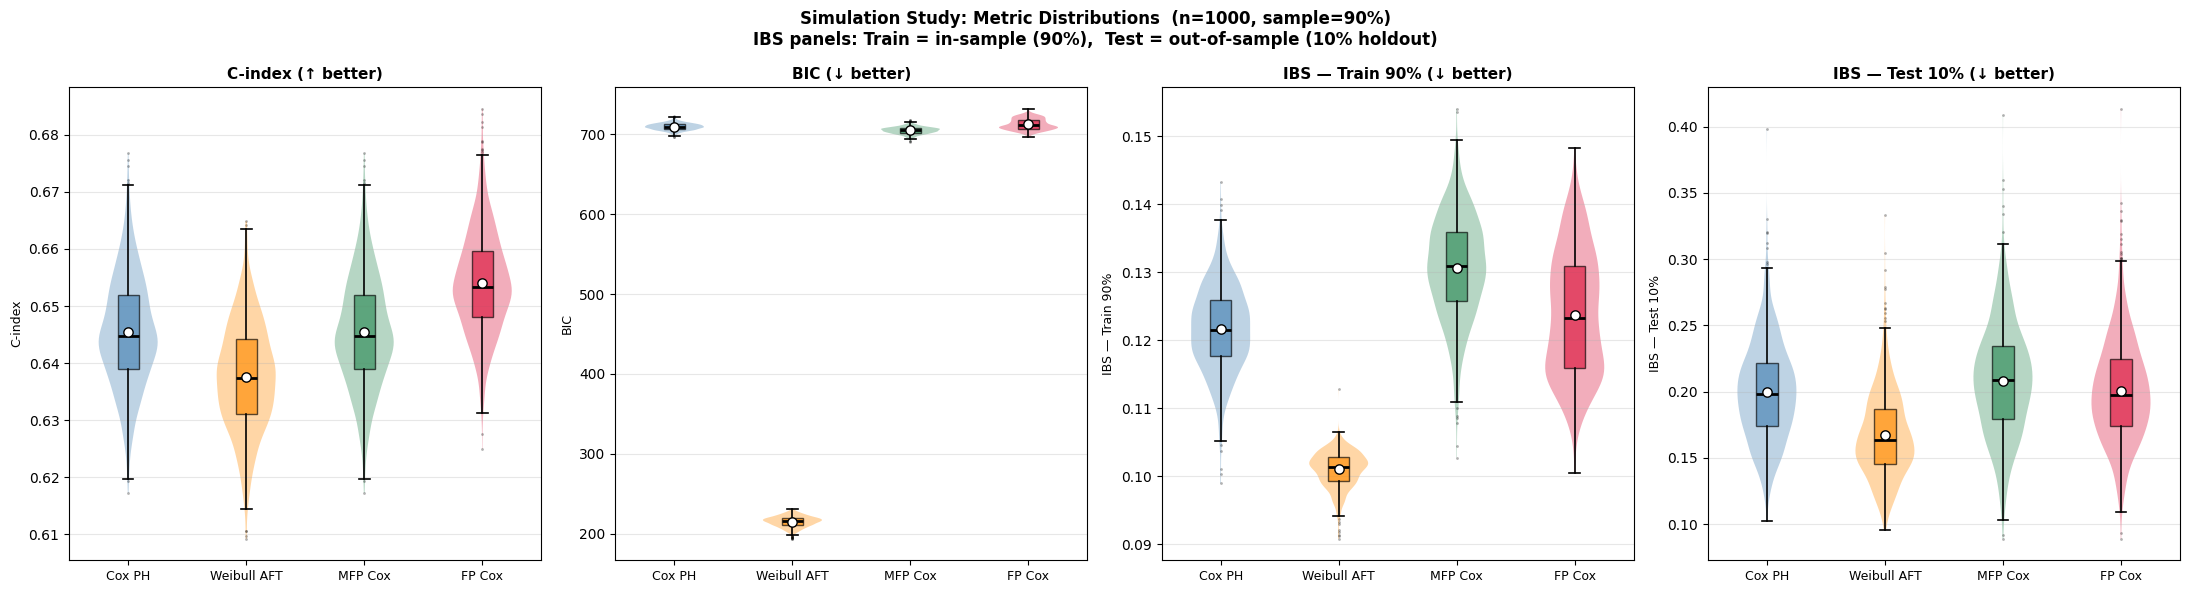

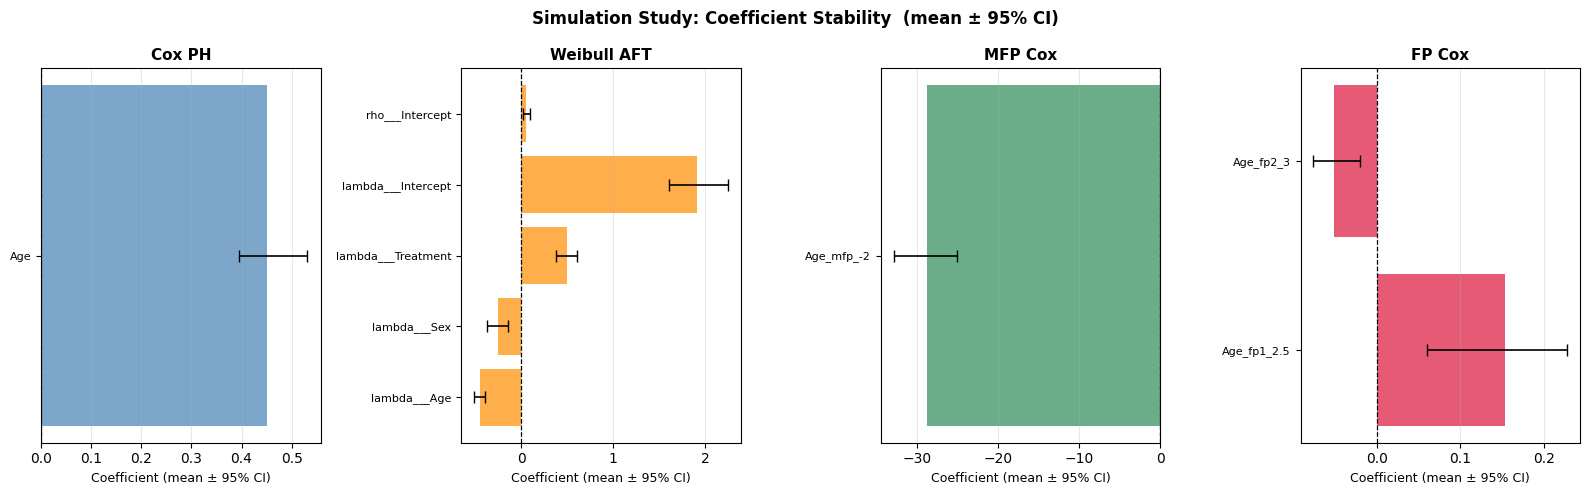


SIMULATION STUDY  (n_sims=1000, sample_frac=90%)
  FP powers FIXED from prior optimize() call.
  Models: Cox PH, Weibull AFT, MFP Cox, FP Cox
  Each iteration: 376 / 418 rows (stratified by event status)
  IBS reported: training (90%) AND test (10% holdout)

  Iteration   100 / 1000 complete  (failed so far: 0)
  Iteration   200 / 1000 complete  (failed so far: 0)
  Iteration   300 / 1000 complete  (failed so far: 0)
  Iteration   400 / 1000 complete  (failed so far: 0)
  Iteration   500 / 1000 complete  (failed so far: 0)
  Iteration   600 / 1000 complete  (failed so far: 0)
  Iteration   700 / 1000 complete  (failed so far: 0)
  Iteration   800 / 1000 complete  (failed so far: 0)
  Iteration   900 / 1000 complete  (failed so far: 0)
  Iteration  1000 / 1000 complete  (failed so far: 0)

  Completed 1000 iterations  (failed: 0)

SIMULATION SUMMARY — PERFORMANCE METRICS

  ── Cox PH (traditional) ──
  Metric                  Mean         Std         CV%        2.5%      Median       9

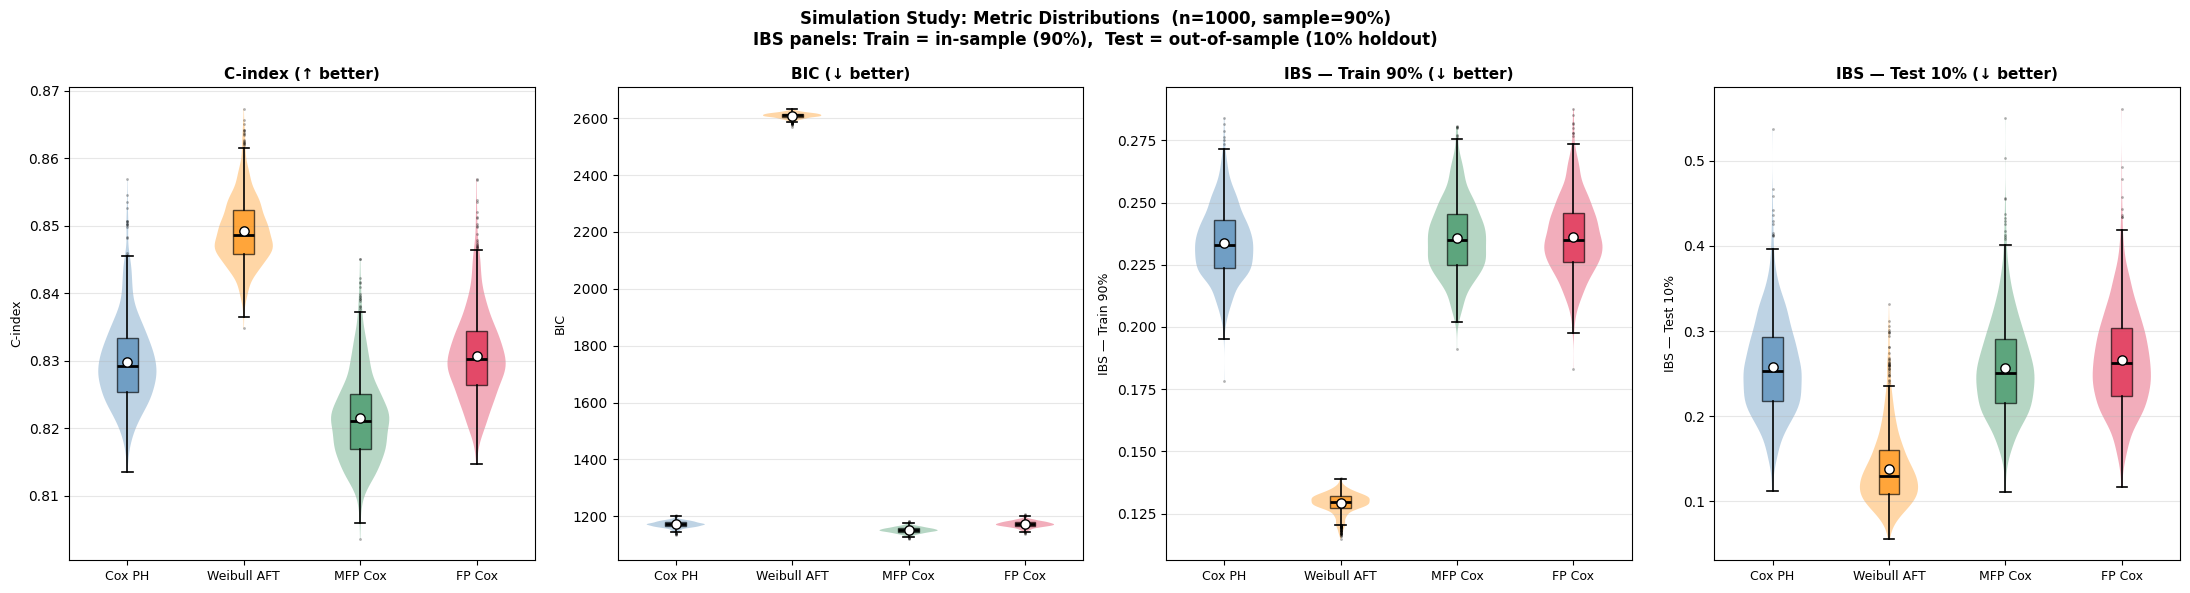

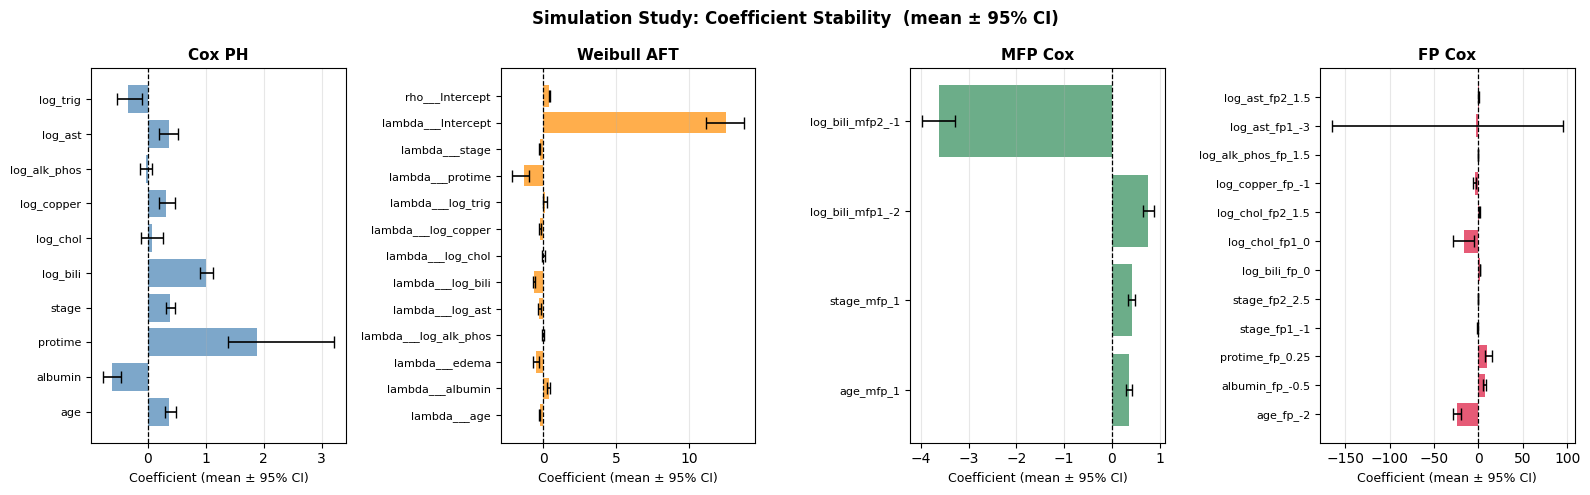


SIMULATION STUDY  (n_sims=1000, sample_frac=90%)
  FP powers FIXED from prior optimize() call.
  Models: Cox PH, Weibull AFT, MFP Cox, FP Cox
  Each iteration: 617 / 686 rows (stratified by event status)
  IBS reported: training (90%) AND test (10% holdout)

  Iteration   100 / 1000 complete  (failed so far: 0)
  Iteration   200 / 1000 complete  (failed so far: 0)
  Iteration   300 / 1000 complete  (failed so far: 0)
  Iteration   400 / 1000 complete  (failed so far: 0)
  Iteration   500 / 1000 complete  (failed so far: 0)
  Iteration   600 / 1000 complete  (failed so far: 0)
  Iteration   700 / 1000 complete  (failed so far: 0)
  Iteration   800 / 1000 complete  (failed so far: 0)
  Iteration   900 / 1000 complete  (failed so far: 0)
  Iteration  1000 / 1000 complete  (failed so far: 0)

  Completed 1000 iterations  (failed: 0)

SIMULATION SUMMARY — PERFORMANCE METRICS

  ── Cox PH (traditional) ──
  Metric                  Mean         Std         CV%        2.5%      Median       9

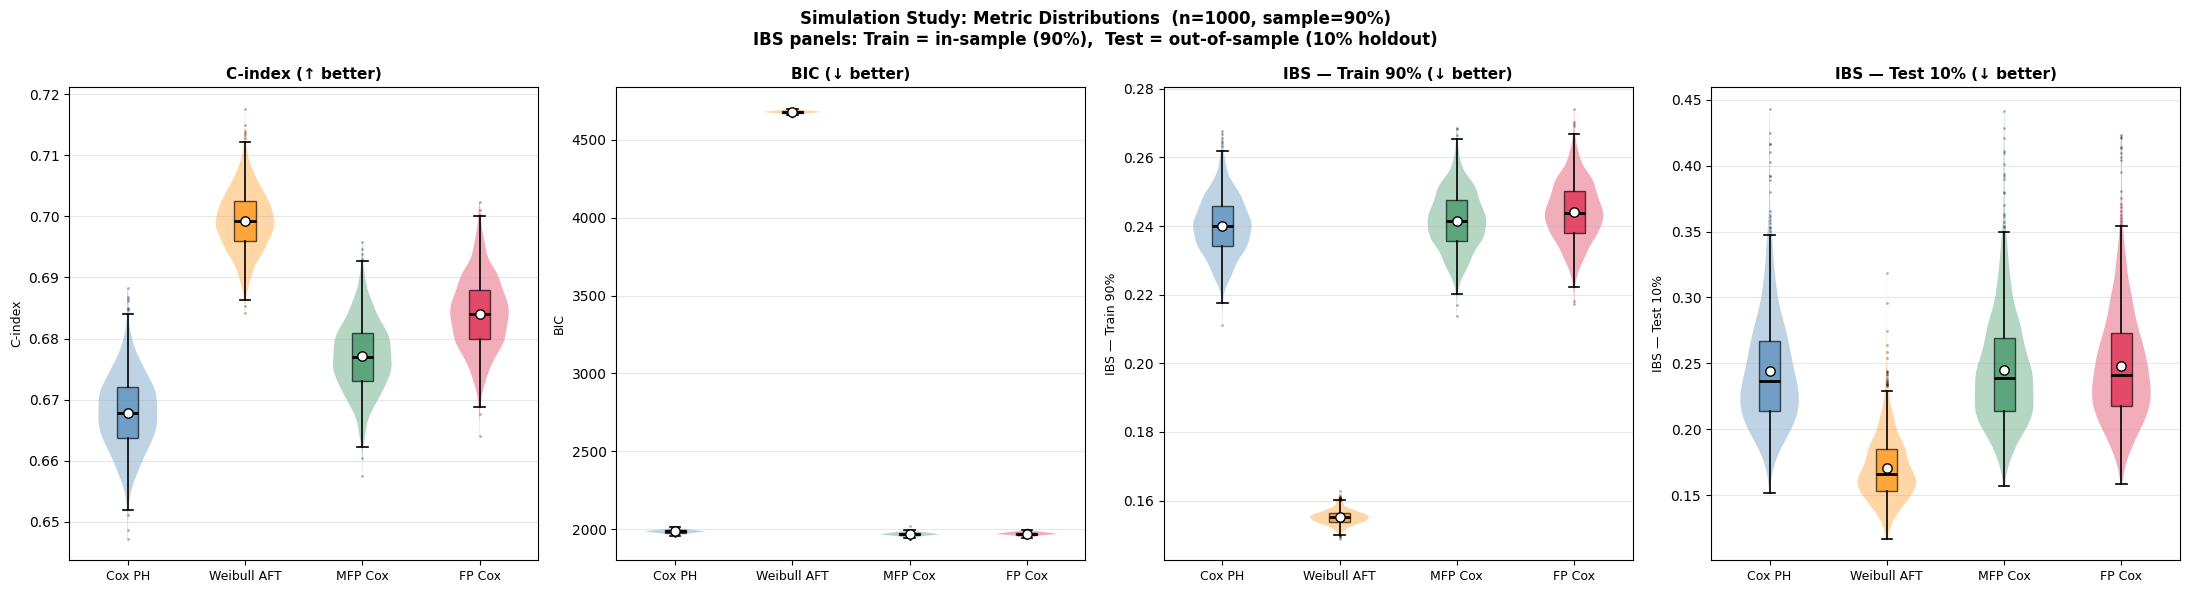

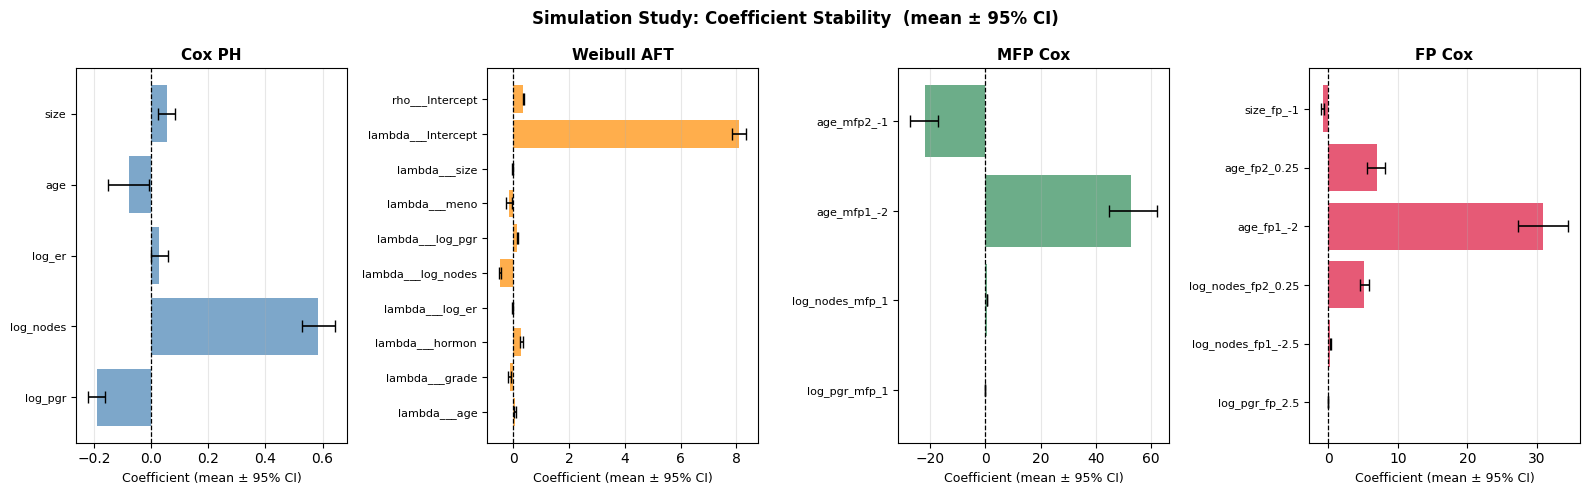

In [25]:

# ── Simulation Study ────────────────────────────────────────────────────────
#
# Run AFTER optimize() has been called on each dataset.
#
# Design
# ------
# • Each of the n_sims iterations randomly draws 90% of the dataset
#   (stratified subsample without replacement, preserving event rate).
# • FP powers are FIXED (post-selection); only coefficients are re-estimated.
# • Three models compared: Cox PH, Weibull AFT, FP Cox.
# • Collects C-index, BIC, IBS per model + all coefficients / parameters.
#
# Outputs
# -------
# • Console table: mean ± std ± CV% ± 95% CI for every metric and coefficient.
# • Plot 1: Violin + box distributions of C-index, BIC, IBS per model.
# • Plot 2: Forest plots of coefficient means with 95% CIs.

# ── Dataset 1: Simulated ─────────────────────────────────────────────────────
sim_results_sd = optimizer_sd.run_simulation_study(
    n_sims              = 1000,
    sample_frac         = 0.90,
    seed                = 42,
    show_progress_every = 100,
)

# ── Dataset 2: PBC ────────────────────────────────────────────────────────
sim_results_pbc = optimizer_pbc.run_simulation_study(
    n_sims              = 1000,
    sample_frac         = 0.90,
    seed                = 42,
    show_progress_every = 100,
)

# ── Dataset 3: GBSG ──────────────────────────────────────────────────────────
sim_results_gb = optimizer_gb.run_simulation_study(
    n_sims              = 1000,
    sample_frac         = 0.90,
    seed                = 42,
    show_progress_every = 100,
)


In [26]:

# ── Cross-dataset Simulation Comparison ──────────────────────────────────────
#
# After all three simulation studies are complete, this cell aggregates the
# mean ± std of the key metrics across datasets into a single comparison table.

def _sim_comparison_table(results_dict):
    """
    results_dict : { dataset_name : sim_results_dict }
    Prints a wide comparison table: metric × (dataset × model).
    """
    bar = "=" * 90
    print(f"\n{bar}")
    print("CROSS-DATASET SIMULATION COMPARISON — Mean (± Std)")
    print(bar)

    metric_map = {
        "C-index": [("Cox PH",      "cox_cindex"),
                    ("Weibull AFT", "aft_cindex"),
                    ("MFP Cox",    "mfp_cindex"),
                    ("FP Cox",      "fp_cindex")],
        "BIC"    : [("Cox PH",      "cox_bic"),
                    ("Weibull AFT", "aft_bic"),
                    ("MFP Cox",    "mfp_bic"),
                    ("FP Cox",      "fp_bic")],
        "IBS (train — 90% subsample)": [
                    ("Cox PH",       "cox_ibs_train"),
                    ("Weibull AFT",  "aft_ibs_train"),
                    ("MFP Cox",     "mfp_ibs_train"),
                    ("FP Cox",       "fp_ibs_train")],
        "IBS (test  — 10% holdout)": [
                    ("Cox PH",       "cox_ibs_test"),
                    ("Weibull AFT",  "aft_ibs_test"),
                    ("MFP Cox",     "mfp_ibs_test"),
                    ("FP Cox",       "fp_ibs_test")],
    }

    ds_names = list(results_dict.keys())

    for metric_name, model_cols in metric_map.items():
        print(f"\n  ── {metric_name} ──")
        # Header
        hdr = f"  {'Model':<22}"
        for ds in ds_names:
            hdr += f"  {ds:>28}"
        print(hdr)
        print(f"  {'-' * (22 + 30 * len(ds_names))}")
        for model_name, col in model_cols:
            row = f"  {model_name:<22}"
            for ds in ds_names:
                mdf = results_dict[ds]["metrics_df"]
                if col in mdf.columns:
                    s = mdf[col].dropna()
                    row += f"  {s.mean():>12.4f} ± {s.std():<12.4f}"
                else:
                    row += f"  {'N/A':>28}"
            print(row)

    # Overfitting gap: IBS(train) - IBS(test)
    print(f"\n  ── IBS Overfitting Gap  [IBS(train) - IBS(test), lower = less overfit] ──")
    gap_models = [
        ("Cox PH",      "cox_ibs_train",  "cox_ibs_test"),
        ("Weibull AFT", "aft_ibs_train",  "aft_ibs_test"),
        ("MFP Cox",    "mfp_ibs_train",  "mfp_ibs_test"),
        ("FP Cox",      "fp_ibs_train",   "fp_ibs_test"),
    ]
    hdr2 = f"  {'Model':<22}"
    for ds in ds_names:
        hdr2 += f"  {ds:>28}"
    print(hdr2)
    print(f"  {'-' * (22 + 30 * len(ds_names))}")
    for model_name, col_train, col_test in gap_models:
        row = f"  {model_name:<22}"
        for ds in ds_names:
            mdf = results_dict[ds]["metrics_df"]
            if col_train in mdf.columns and col_test in mdf.columns:
                gap = (mdf[col_train] - mdf[col_test]).dropna()
                row += f"  {gap.mean():>12.4f} ± {gap.std():<12.4f}"
            else:
                row += f"  {'N/A':>28}"
        print(row)

    print(f"\n{bar}")

_sim_comparison_table({
    "Simulated" : sim_results_sd,
    "PBC"       : sim_results_pbc,
    "GBSG"      : sim_results_gb,
})



CROSS-DATASET SIMULATION COMPARISON — Mean (± Std)

  ── C-index ──
  Model                                      Simulated                           PBC                          GBSG
  ----------------------------------------------------------------------------------------------------------------
  Cox PH                        0.6454 ± 0.0096              0.8298 ± 0.0064              0.6679 ± 0.0061      
  Weibull AFT                   0.6375 ± 0.0093              0.8491 ± 0.0049              0.6993 ± 0.0050      
  MFP Cox                       0.6454 ± 0.0096              0.8214 ± 0.0064              0.6771 ± 0.0057      
  FP Cox                        0.6540 ± 0.0089              0.8307 ± 0.0065              0.6841 ± 0.0059      

  ── BIC ──
  Model                                      Simulated                           PBC                          GBSG
  ----------------------------------------------------------------------------------------------------------------
  Cox PH  